# Mini Project on Cancer Patient Dataset-China

Data source: https://www.kaggle.com/datasets/ak0212/cancer-patient-dataset-china

The dataset contains information of 10,000 unique cancer patients covering age, gender, occupation, cancer type, survival status etc.  

The data is different from other similar datasets with focus on cancer patients as it uniquely contains socio economic status data like occupation, insurance type and living area (urban or rural).  

While the role of health and lifestyle related attributes like smoking status or BMI in patients’ survival is more intuitive, this study will apply machine learning methods (logistic regression and decision tree) for predicting the survival outcome of patients and also try to answer the question if socio economic status is also vital to patients' survival outcome using coefficients and SHAP.

H1: The bigger the tumor is and the later the cancer is diagnosed(stage), the less likely the patients are expected to survive.  
H2: Smoking, alcohol consumption and unhealthy BMI (too low/too high) contribute to lower survival chances.  
H3: The combination of treatment methods increases the survival chance than applying a single method.  
H4: Socio-economic background actively affects survival outcomes. Patients who live in urban areas, hold a better occupation (in terms of expected salary) or have more advanced insurance are more likely to survive.

Final comment on variables: only Stage at Diagnosis has a strong impact on patients' survival outcome. Some trivial effects are witnessed in other variables like cancer type, smoking habits and age etc. Socio economic background does not play an important role based on the results of this research.

For this data, we must recognize its limitation in terms of size(~10000) and number of variables(especially clinical variables).

## Data Acquisition and Cleaning

In [1]:
# Import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# get ready to load the dataset from Kaggle
# I have my token ready from Kaggle
import sys
#!{sys.executable} -m pip install kaggle
import kaggle

In [3]:
# Load the data from web
kaggle.api.dataset_download_files("ak0212/cancer-patient-dataset-china", path="./", unzip=True, quiet=False) 
# unzip it so we get the csv

Dataset URL: https://www.kaggle.com/datasets/ak0212/cancer-patient-dataset-china


100%|██████████| 310k/310k [00:00<00:00, 359MB/s]

In [2]:
# read the csv file
cancer_data = pd.read_csv("cancer_patients_china.csv")

# inspect the data, show the first 5 rows using head()
print("\nThe first 5 rows in cancer_data:")
display(cancer_data.iloc[:, :15].head())
# I found 29 columns is too many for this diaplay so I need to separate the columns by half
display(cancer_data.iloc[:, 15:].head())

# show the data type of all columns using info()
print("\nThe data type of all columns in cancer_data:\n")
display(cancer_data.info())

# show the descriptive statistics of the numerical columns using describe()
print("\nThe descriptive statistics of the numerical columns in cancer_data:")
display(cancer_data.describe())


The first 5 rows in cancer_data:


,Patient_ID,Age,Gender,Province,Urban_Rural,Ethnicity,Occupation,Insurance_Type,Family_History,Cancer_Type,Stage_at_Diagnosis,Diagnosis_Date,Symptoms,Metastasis_Sites,Tumor_Size
0,CN_CA_00001,70,Male,Yunnan,Urban,Han,Retired,Self-pay,No,Esophageal,I,2012-07-01,"Fatigue, Pain","Liver, Bone",9.5
1,CN_CA_00002,71,Male,Henan,Urban,Hui,Factory Worker,URBMI,No,Colorectal,II,2016-03-03,"Lump, Swelling","Liver, Bone",12.6
2,CN_CA_00003,42,Male,Hubei,Rural,Han,Unemployed,Self-pay,No,Breast,III,2015-01-03,"Nausea, Vomiting","Liver, Bone",0.7
3,CN_CA_00004,56,Female,Zhejiang,Rural,Han,Office Worker,NRCMS,No,Colorectal,IV,2012-04-19,"Nausea, Vomiting",Lymph Nodes,4.2
4,CN_CA_00005,29,Male,Guizhou,Rural,Han,Farmer,UEBMI,No,Breast,II,2022-03-26,Blood in Stool,Lymph Nodes,13.5


,Treatment_Types,Surgery_Date,Chemotherapy_Drugs,Radiation_Sessions,Immunotherapy,Targeted_Therapy,Survival_Status,Survival_Months,Recurrence_Status,Smoking_History,Alcohol_Use,BMI,Biomarker_1,Biomarker_2
0,"Surgery, Chemotherapy",2012-07-23,"Cisplatin, Paclitaxel",26,No,Yes,Alive,NaN,No,Never,Occasional,19.0,Negative,Low
1,"Surgery, Chemotherapy",2018-09-30,"Gemcitabine, Carboplatin",29,No,No,Alive,NaN,No,Former,Regular,32.9,Negative,Medium
2,"Surgery, Chemotherapy",2016-07-25,NaN,10,Yes,No,Deceased,59.0,Yes,Never,Never,32.3,Negative,NaN
3,NaN,NaN,"Gemcitabine, Carboplatin",9,No,Yes,Deceased,49.0,No,Former,Regular,20.0,Positive,Low
4,"Surgery, Chemotherapy",2022-06-28,NaN,29,Yes,No,Alive,NaN,Yes,Former,Never,28.8,Negative,Medium



The data type of all columns in cancer_data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Province            10000 non-null  object 
 4   Urban_Rural         10000 non-null  object 
 5   Ethnicity           10000 non-null  object 
 6   Occupation          10000 non-null  object 
 7   Insurance_Type      10000 non-null  object 
 8   Family_History      10000 non-null  object 
 9   Cancer_Type         10000 non-null  object 
 10  Stage_at_Diagnosis  10000 non-null  object 
 11  Diagnosis_Date      10000 non-null  object 
 12  Symptoms            9499 non-null   object 
 13  Metastasis_Sites    6772 non-null   object 
 14  Tumor_Size          10000 non-null  float64
 15  Treatme

None


The descriptive statistics of the numerical columns in cancer_data:


,Age,Tumor_Size,Radiation_Sessions,Survival_Months,BMI
count,10000.000000,10000.000000,10000.000000,5245.000000,10000.000000
mean,61.179600,7.749400,15.008700,30.648236,24.967790
std,19.664491,4.158616,8.859496,17.399850,5.723172
min,18.000000,0.500000,0.000000,1.000000,15.000000
25%,46.000000,4.200000,8.000000,15.000000,20.000000
50%,64.000000,7.800000,15.000000,31.000000,25.000000
75%,78.000000,11.300000,23.000000,46.000000,29.800000
max,90.000000,15.000000,30.000000,60.000000,35.000000


The sample size is 10000.  

Most of the columns contain string/object. Age(integer), Tumor_size(float), Radiation_Sessions(integer) and BMI(float) contains numerical values.  

The 2 columns Diagnosis_Date and Surgery_Date records dates but as we are not dealing with the development of cancer in a period, we decide to drop them. WE can also drop Patient_ID. Survival_Months is not important to our research. Metastasis_Sites is especially problematic as almost half of the values are missing so better just drop this whole column.  

If we drop Diagnosis_Date, Survival_Months and Metastasis_Sites, there are still 5 coulmns with missing data.

For biomarkers, the original data lack description so we don't know when(before/after treatment) the biomarkers are recorded. So to keep it simple, we will drop them. 

There are missing values in Treatment_Types and Surgery_Date, Chemotherapy_Drugs, Radiation_Sessions, Immunotherapy and Targeted_Therapy. Maybe we can try to fill in missing values later by combining the recorded values in these columns.

For numerical columns, the patients' age range from 18 to 90 with mean value being about 61.2. This means the in this data, we find more elderly patients. But a good news is we don't see any extreme/unrealistic value here. The tumor size is from 0.5 to 15 cm wit mean value at around 7.7 cm. The BMI goes from 15 to 35. After searching for Chinese BMI standard, BMI under 18.5 would be underweight and greater than or equal to 28 is obese. We do find patients with unhealthy BMI here. 

In [3]:
# let's drop the date related columns.
cancer_data.drop(['Patient_ID', 'Diagnosis_Date', 'Survival_Months','Metastasis_Sites', 'Biomarker_1', 'Biomarker_2'], axis = 1, inplace = True)

In [4]:
# The updated data
display(cancer_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 10000 non-null  int64  
 1   Gender              10000 non-null  object 
 2   Province            10000 non-null  object 
 3   Urban_Rural         10000 non-null  object 
 4   Ethnicity           10000 non-null  object 
 5   Occupation          10000 non-null  object 
 6   Insurance_Type      10000 non-null  object 
 7   Family_History      10000 non-null  object 
 8   Cancer_Type         10000 non-null  object 
 9   Stage_at_Diagnosis  10000 non-null  object 
 10  Symptoms            9499 non-null   object 
 11  Tumor_Size          10000 non-null  float64
 12  Treatment_Types     9483 non-null   object 
 13  Surgery_Date        2425 non-null   object 
 14  Chemotherapy_Drugs  5950 non-null   object 
 15  Radiation_Sessions  10000 non-null  int64  
 16  Immun

None

In [5]:
# let's explore the "object"columns, find how many unique values they have and show all unique values
pd.set_option('display.max_colwidth', None)  # Show full content
pd.set_option('display.max_columns', None)  # Show all columns
# I learnt that without this part I cannot see all values

unique = pd.DataFrame({
    'n_unique': cancer_data.select_dtypes('object').nunique(),
    'sample_values': cancer_data.select_dtypes('object').apply(lambda x: x.unique())
})

display(unique)

,n_unique,sample_values
Gender,2,"[Male, Female]"
Province,32,"[Yunnan, Henan, Hubei, Zhejiang, Guizhou, Jilin, Hebei, Hunan, Tibet, Chongqing, Jiangxi, Taiwan, Liaoning, Shanxi, Gansu, Shaanxi, Fujian, Anhui, Macau, Shandong, Tianjin, Ningxia, Shanghai, Hong Kong, Heilongjiang, Xinjiang, Inner Mongolia, Sichuan, Jiangsu, Beijing, Guangdong, Qinghai]"
Urban_Rural,2,"[Urban, Rural]"
Ethnicity,10,"[Han, Hui, Uyghur, Manchu, Zhuang, Yi, Miao, Mongol, Tujia, Tibetan]"
Occupation,5,"[Retired, Factory Worker, Unemployed, Office Worker, Farmer]"
Insurance_Type,4,"[Self-pay, URBMI, NRCMS, UEBMI]"
Family_History,2,"[No, Yes]"
Cancer_Type,7,"[Esophageal, Colorectal, Breast, Stomach, Liver, Cervical, Lung]"
Stage_at_Diagnosis,4,"[I, II, III, IV]"
Symptoms,5,"[Fatigue, Pain, Lump, Swelling, Nausea, Vomiting, Blood in Stool, Cough, Weight Loss, nan]"


Problem 1: In the column Symptoms, it seems that some values contain "," and created confusion in our "unique" dataframe. The same for Treatment_Types. This can be solved later.

Problem 2: Province and Ethnicity contains a lot of unique values. The importance of Province in this study need to be reconsidered as its values are so diversed. But this might be solved by creating a columns based on whether the patients are in the east or west in China. Around 90% of the population in China belong to Han Ethnicity. If they still makes the majority in this dataset, Ethnicity should be removed.  

Problem 3: Some cancer types here are gender-biasd. Must check if there are mistakes in the data.

In [6]:
# of course we can check symptoms and treatment types in a very simple way
print(cancer_data.Symptoms.unique())
print(cancer_data.Treatment_Types.unique())

['Fatigue, Pain' 'Lump, Swelling' 'Nausea, Vomiting' 'Blood in Stool'
 'Cough, Weight Loss' nan]
['Surgery, Chemotherapy' nan 'Targeted Therapy' 'Radiation, Immunotherapy'
 'Chemotherapy']


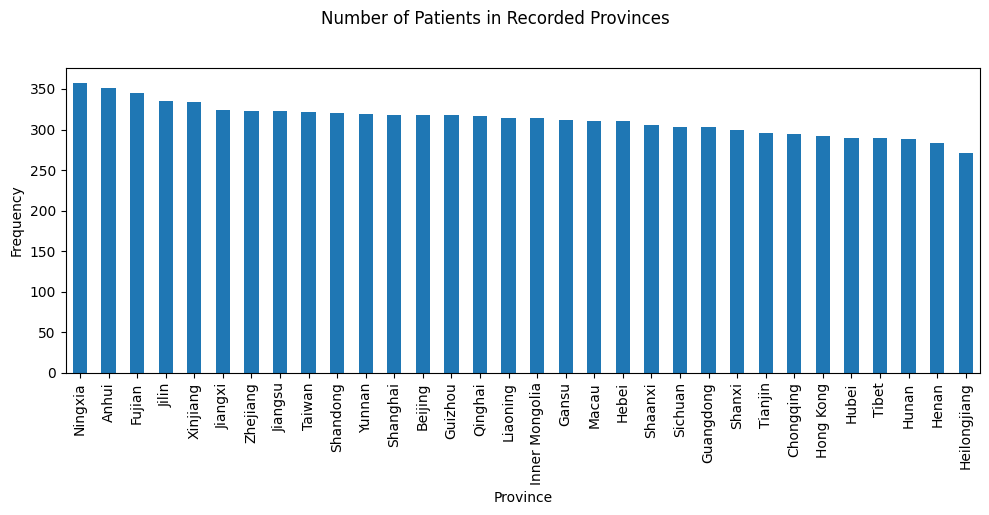

In [7]:
# let's check the value frequncy in Province and Ethnicity
province_counts = cancer_data['Province'].value_counts()

# Create a bar plot
province_counts.plot(kind = 'bar', figsize = (10,5))

# plt.title('Distribution of Province')
plt.suptitle('Number of Patients in Recorded Provinces', y = 1.02) # Add a title
plt.xlabel('Province')
plt.ylabel('Frequency')
plt.xticks(rotation = 90) # need to rotate to see all provicne names
plt.tight_layout()
plt.show()

Well, the most common patient province does not have a dramatic difference(~350 vs ~275) from the least common patient province. The Heihe–Tengchong Line divides China into two parts, the east side(densely populated, likely more developed, 43% land, but 94–96% population) and the west side. We can work on this later.

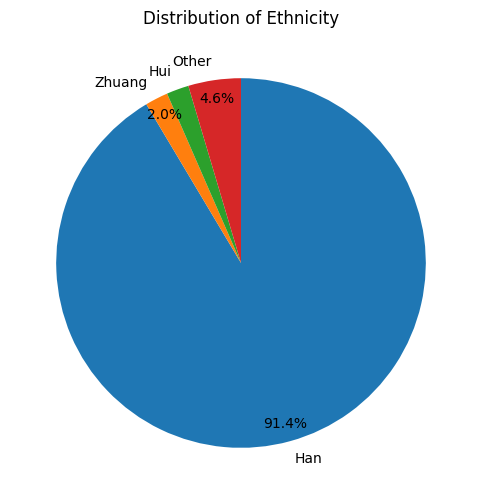

In [8]:
# Create a pir chart for Ethnicity
# I expect Han ethnicty to make a great part so I will not use bar plot as for Province but a pie chart
ethnicity_counts = cancer_data['Ethnicity'].value_counts()

# Pie chart
# plt.figure(figsize=(6,6))
# plt.pie(ethnicity_counts, 
#        labels=ethnicity_counts.index,   # category names
#        autopct='%1.1f%%',              # show percentages
#        startangle=90,                  # rotate to start at 12 o'clock
#        counterclock=False)             # use clockwise order
# plt.title('Distribution of Ethnicity')
# plt.show()
# This plot makes the point but too many ethnicity value names are mixed in the corner

# Sort values
# Let's give only the top 3 values labels in the pit chart
top3 = ethnicity_counts.head(3)
others = ethnicity_counts[3:].sum()
plot_counts = pd.concat([top3, pd.Series({'Other': others})]) # If I use ignore_index, I will see 0,1,2,3 intead of the actual ethnicity names.

# Recreate lables, they are either the top 3 value names or "Other" 
labels = plot_counts.index

# Create the pie chart
plt.figure(figsize = (6,6))
plt.pie(plot_counts.values, 
        labels = labels, 
        autopct = lambda p: f'{p:.1f}%' if p >= 2 else '',  # show % only for slices >= 2%
        startangle = 90,
        counterclock = False,
        pctdistance = 0.9)    
# distance of % label from center. Without this, I still know 2.0% should belong to Zhuang(maybe) and 4.6% should belong to Other but I want to make sure
plt.title('Distribution of Ethnicity')
plt.show()

Now it will not be so meaning to keep Ethnicity as Han takes 91.4% of the data.

In [9]:
# Let's drop Ethnicity
cancer_data.drop('Ethnicity', axis = 1, inplace = True)

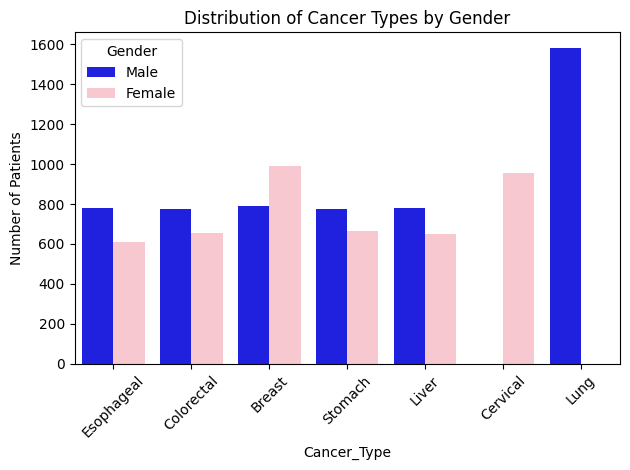

In [10]:
# Let's check the relationship between gender and cancer type.
# For example, cervical cancer is female-only. The occurrence of breast cancer in male is extremly rare though not 0. 
# plt.figure(figsize=(10,6))
sns.countplot(data = cancer_data, 
              x = 'Cancer_Type', 
              hue = 'Gender', 
              palette = {'Female': 'pink', 'Male': 'blue'}) # I am using stereotypical colors for gender
plt.title('Distribution of Cancer Types by Gender')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

We do not see fatal mistakes like cervical cancer appear in male but breast cancer has a lot of male patients. After some research, it seems that the chance of a male having breast cnacer is about 0.1% and the reason could be "genetic or hormonal". For female, the risk would be 12–13%. 

All patients of lung cancer in the dataset are male.  

The result we see in the plot is not impossible and we need to keep in mind that the dataset only has 10000 entries.

In [11]:
# Save the current data just in case
cancer_data.to_csv('cancer_data_smaller.csv', index=False)

### Don't forget to handle missing values in Symptoms and Treatment_Types. (Treatment-specific columns are  is kept for now to help with replacing NA)

In [2]:
cancer_to_fill = pd.read_csv("cancer_data_smaller.csv") # import the data

In [3]:
# refresh our memeory
print(cancer_to_fill.Treatment_Types.unique())

['Surgery, Chemotherapy' nan 'Targeted Therapy' 'Radiation, Immunotherapy'
 'Chemotherapy']


In [4]:
# if there is a date for surgery, the treatment must contain "surgery"
# let's check if there is any rows with a recorded surgery date but a missing value in Treatment_Types.
first_condition = cancer_to_fill['Treatment_Types'].isna()
second_condition = cancer_to_fill['Surgery_Date'].isna()
print(f'The number of rows fulfilling the conditions above is {cancer_to_fill[first_condition & ~second_condition].shape[0]}')

The number of rows fulfilling the conditions above is 0


In [5]:
# if there is a "Yes" in "Immunotherapy", the treatment must contain "immunotherapy" 
third_condition = cancer_to_fill['Immunotherapy'] == 'Yes'
print(f'The number of rows fulfilling the conditions above is {cancer_to_fill[first_condition & third_condition].shape[0]}')

The number of rows fulfilling the conditions above is 203


In [7]:
# Do the same for "Targeted_Therapy"
fourth_condition = cancer_to_fill['Targeted_Therapy'] == 'Yes'
print(f'The number of rows fulfilling the conditions above is {cancer_to_fill[first_condition & fourth_condition].shape[0]}')

The number of rows fulfilling the conditions above is 138


In [8]:
# a check
cancer_to_fill[first_condition & third_condition].head()

,Age,Gender,Province,Urban_Rural,Occupation,Insurance_Type,Family_History,Cancer_Type,Stage_at_Diagnosis,Symptoms,...,Surgery_Date,Chemotherapy_Drugs,Radiation_Sessions,Immunotherapy,Targeted_Therapy,Survival_Status,Recurrence_Status,Smoking_History,Alcohol_Use,BMI
10,81,Female,Jiangxi,Urban,Retired,UEBMI,Yes,Esophageal,III,"Lump, Swelling",...,NaN,NaN,29,Yes,No,Alive,Yes,Current,Never,17.5
22,29,Male,Yunnan,Urban,Retired,Self-pay,No,Lung,IV,"Nausea, Vomiting",...,NaN,"Gemcitabine, Carboplatin",28,Yes,No,Deceased,Yes,Never,Never,28.8
121,50,Male,Yunnan,Urban,Unemployed,UEBMI,No,Colorectal,III,"Fatigue, Pain",...,NaN,"Gemcitabine, Carboplatin",18,Yes,No,Alive,Yes,Former,Occasional,19.9
149,51,Male,Hong Kong,Rural,Factory Worker,URBMI,Yes,Liver,II,NaN,...,NaN,NaN,14,Yes,No,Alive,No,Former,Never,29.2
224,89,Male,Xinjiang,Rural,Factory Worker,UEBMI,Yes,Liver,III,"Fatigue, Pain",...,NaN,"Cisplatin, Paclitaxel",10,Yes,Yes,Deceased,No,Never,Occasional,31.5


In [9]:
cancer_to_fill[first_condition & fourth_condition].head()

,Age,Gender,Province,Urban_Rural,Occupation,Insurance_Type,Family_History,Cancer_Type,Stage_at_Diagnosis,Symptoms,...,Surgery_Date,Chemotherapy_Drugs,Radiation_Sessions,Immunotherapy,Targeted_Therapy,Survival_Status,Recurrence_Status,Smoking_History,Alcohol_Use,BMI
3,56,Female,Zhejiang,Rural,Office Worker,NRCMS,No,Colorectal,IV,"Nausea, Vomiting",...,NaN,"Gemcitabine, Carboplatin",9,No,Yes,Deceased,No,Former,Regular,20.0
224,89,Male,Xinjiang,Rural,Factory Worker,UEBMI,Yes,Liver,III,"Fatigue, Pain",...,NaN,"Cisplatin, Paclitaxel",10,Yes,Yes,Deceased,No,Never,Occasional,31.5
262,51,Female,Beijing,Urban,Farmer,UEBMI,No,Esophageal,II,"Fatigue, Pain",...,NaN,"Gemcitabine, Carboplatin",15,No,Yes,Alive,No,Never,Regular,33.7
333,45,Female,Shandong,Urban,Factory Worker,Self-pay,No,Colorectal,III,"Nausea, Vomiting",...,NaN,"Cisplatin, Paclitaxel",6,Yes,Yes,Deceased,Yes,Former,Occasional,19.8
378,53,Male,Anhui,Urban,Unemployed,UEBMI,No,Stomach,I,NaN,...,NaN,"Cisplatin, Paclitaxel",22,No,Yes,Alive,No,Current,Occasional,33.7


We have a new problem. Just by eyeballing the rows we get. There are some rows with "Yes" in both Immunotherapy and Targeted_Therapy. It makes sense still as the two kind of treatment can be applied together. These 2 columns has no missing value. So maybe it is best to leave Treatment_Type as it is and create/update treatment-specific columns based on Surgery_Date, Chemotherapy_Drugs, Immunotherapy and Targeted_Therapy. 

In [10]:
# is radiation exclusive to certain treatments?
pd.crosstab(
    cancer_to_fill['Treatment_Types'],
    cancer_to_fill['Radiation_Sessions'] > 0, # at least once
    rownames = ['Treatment Type'],
    colnames = ['Has Radiation Session']
)

Has Radiation Session,False,True
Treatment Type,,
Chemotherapy,84,2216
"Radiation, Immunotherapy",72,2327
"Surgery, Chemotherapy",81,2344
Targeted Therapy,79,2280


Radiation appears to be a very common treatment method even though it is not mentioned in the names of a few treatment types.

In [11]:
# What about drugs? We do know over 1000 patients has missing value in Chemotherapy_Drugs
pd.crosstab(
    cancer_to_fill['Treatment_Types'],
    ~cancer_to_fill['Chemotherapy_Drugs'].isna(),
    rownames = ['Treatment Type'],
    colnames = ['Has Chemotherapy Drugs']
)

Has Chemotherapy Drugs,False,True
Treatment Type,,
Chemotherapy,925,1375
"Radiation, Immunotherapy",996,1403
"Surgery, Chemotherapy",958,1467
Targeted Therapy,954,1405


Looks like neither chemotherapy drugs or radiation session can lead us to a specific treatment already mentioned in Treatment_Type.

In [12]:
# We can check the relationship between cancer type and stage
pd.crosstab(
    cancer_to_fill['Cancer_Type'],
    cancer_to_fill['Stage_at_Diagnosis'],
    rownames = ['Cancer_Type'],
    colnames = ['Stage_at_Diagnosis']
)

Stage_at_Diagnosis,I,II,III,IV
Cancer_Type,,,,
Breast,348,541,537,357
Cervical,215,271,291,180
Colorectal,293,447,408,281
Esophageal,255,416,435,281
Liver,277,417,434,298
Lung,343,449,476,312
Stomach,309,423,420,286


For now, it looks like all cancer types are more likely to be diagnosed at stage 2 and 3. 

In [13]:
# is symptoms related with a type of cancer or a specific stage
pd.crosstab(
    cancer_to_fill['Cancer_Type'],
    cancer_to_fill['Symptoms'],
    rownames = ['Cancer_Type'],
    colnames = ['Symptoms']
)

Symptoms,Blood in Stool,"Cough, Weight Loss","Fatigue, Pain","Lump, Swelling","Nausea, Vomiting"
Cancer_Type,,,,,
Breast,335,356,352,291,364
Cervical,178,190,191,182,168
Colorectal,260,286,273,253,283
Esophageal,256,261,277,238,278
Liver,254,269,280,267,281
Lung,326,305,299,290,304
Stomach,276,293,255,273,255


In [14]:
pd.crosstab(
    cancer_to_fill['Stage_at_Diagnosis'],
    cancer_to_fill['Symptoms'],
    rownames = ['Stage_at_Diagnosis'],
    colnames = ['Symptoms']
)

Symptoms,Blood in Stool,"Cough, Weight Loss","Fatigue, Pain","Lump, Swelling","Nausea, Vomiting"
Stage_at_Diagnosis,,,,,
I,376,409,370,379,400
II,569,550,588,532,566
III,565,616,583,530,560
IV,375,385,386,353,407


It seems that Symptoms are not strongly correlated with a type of cancer or a stage.

In [15]:
# Get rid of rows with missing values in Symptoms
cancer_to_fill = cancer_to_fill.dropna(subset=['Symptoms'])

In [16]:
# check the data
cancer_to_fill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9499 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9499 non-null   int64  
 1   Gender              9499 non-null   object 
 2   Province            9499 non-null   object 
 3   Urban_Rural         9499 non-null   object 
 4   Occupation          9499 non-null   object 
 5   Insurance_Type      9499 non-null   object 
 6   Family_History      9499 non-null   object 
 7   Cancer_Type         9499 non-null   object 
 8   Stage_at_Diagnosis  9499 non-null   object 
 9   Symptoms            9499 non-null   object 
 10  Tumor_Size          9499 non-null   float64
 11  Treatment_Types     9014 non-null   object 
 12  Surgery_Date        2300 non-null   object 
 13  Chemotherapy_Drugs  5652 non-null   object 
 14  Radiation_Sessions  9499 non-null   int64  
 15  Immunotherapy       9499 non-null   object 
 16  Targeted_Th

We don't expect to drop more rows so eventually we will have 9499 entries.

## Visualization

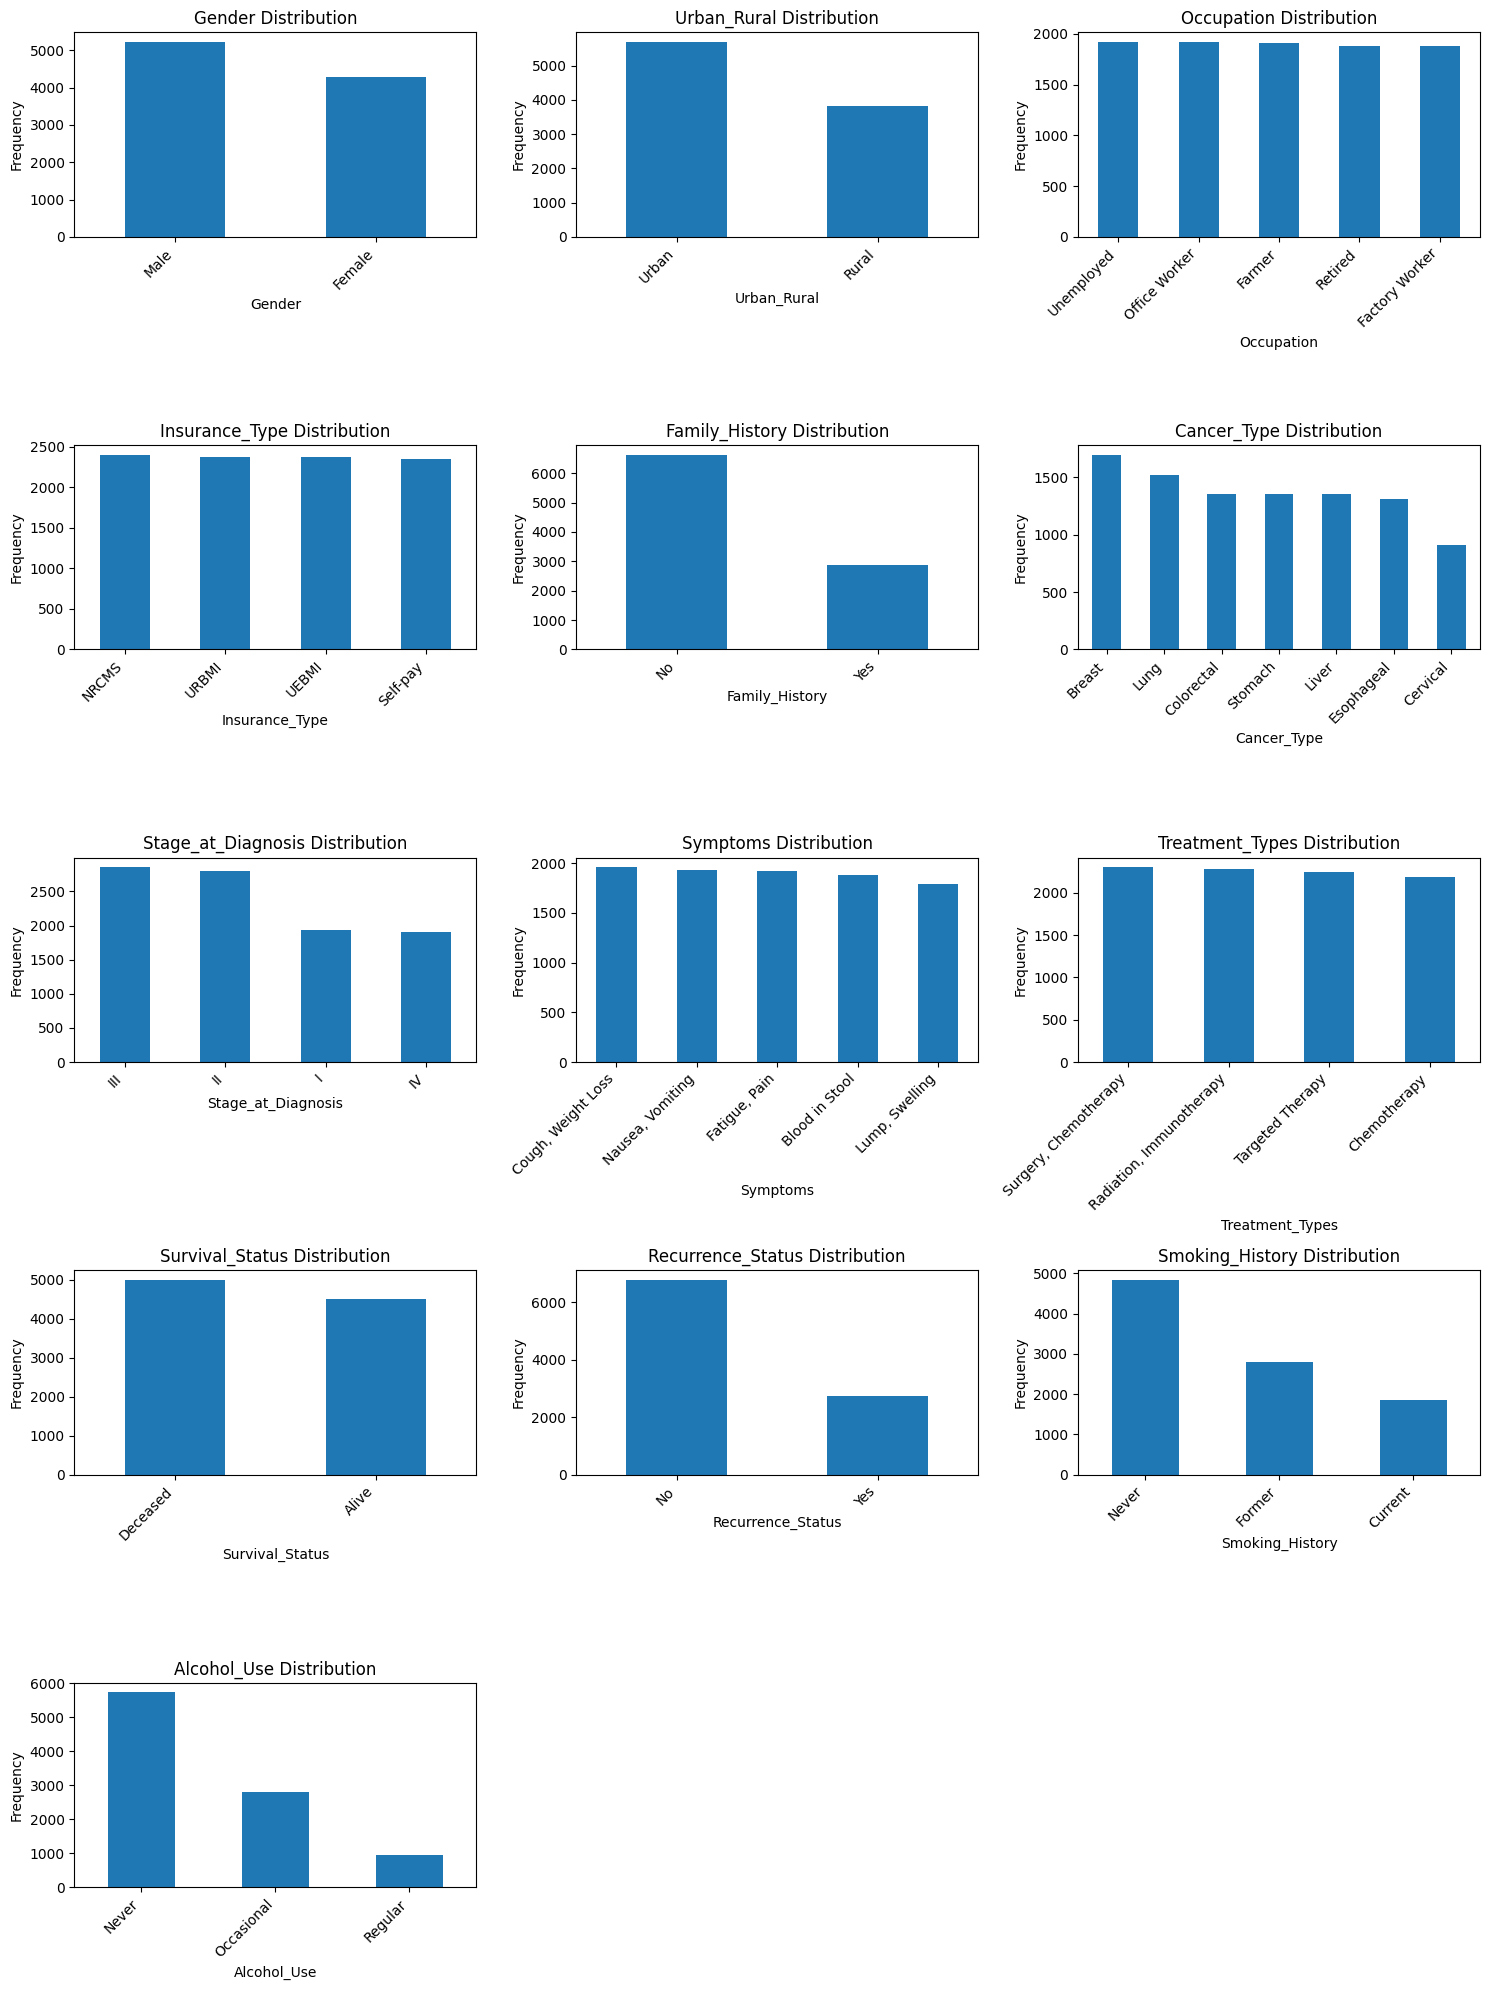

In [17]:
# Before we move forward to create or update columns based on treatment data, let's try to visualize the data at this stage
# Let's apply bar plot to all "object" columns
# get a list of all 'object' columns
obj_cols = cancer_to_fill.select_dtypes('object').columns.tolist()

# Exclude Province as we have already explored it
cols_to_plot = [c for c in obj_cols if c not in ['Province', 'Surgery_Date', 'Chemotherapy_Drugs', 'Immunotherapy', 'Targeted_Therapy']] # treatment_Type can be kept for now

# Number of plots
n_cols = 3  # number of plots per row # I tried 4, but 3 is clearer
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols  # auto-calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(cols_to_plot):
    counts = cancer_to_fill[col].value_counts()
    counts.plot(kind = 'bar', ax = axes[i])
    axes[i].set_title(f'{col} Distribution') # I know by default we will see the column name under the plots but it should be clearer with a title above the plots 
    axes[i].set_ylabel('Frequency')
    axes[i].set_xticklabels(counts.index, rotation = 45, ha = 'right')

# Turn off any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Most of the patients are male(but not great difference in number)/living in urban area/have no family history of cancer/no recurrence. Most patients never smokes or never use alcohol. The distributions in occupation, insurance and symptom look relatively even. More patients were unfortunately deceased when the data is collected but the distribution difference in survival status is not dramatic. 

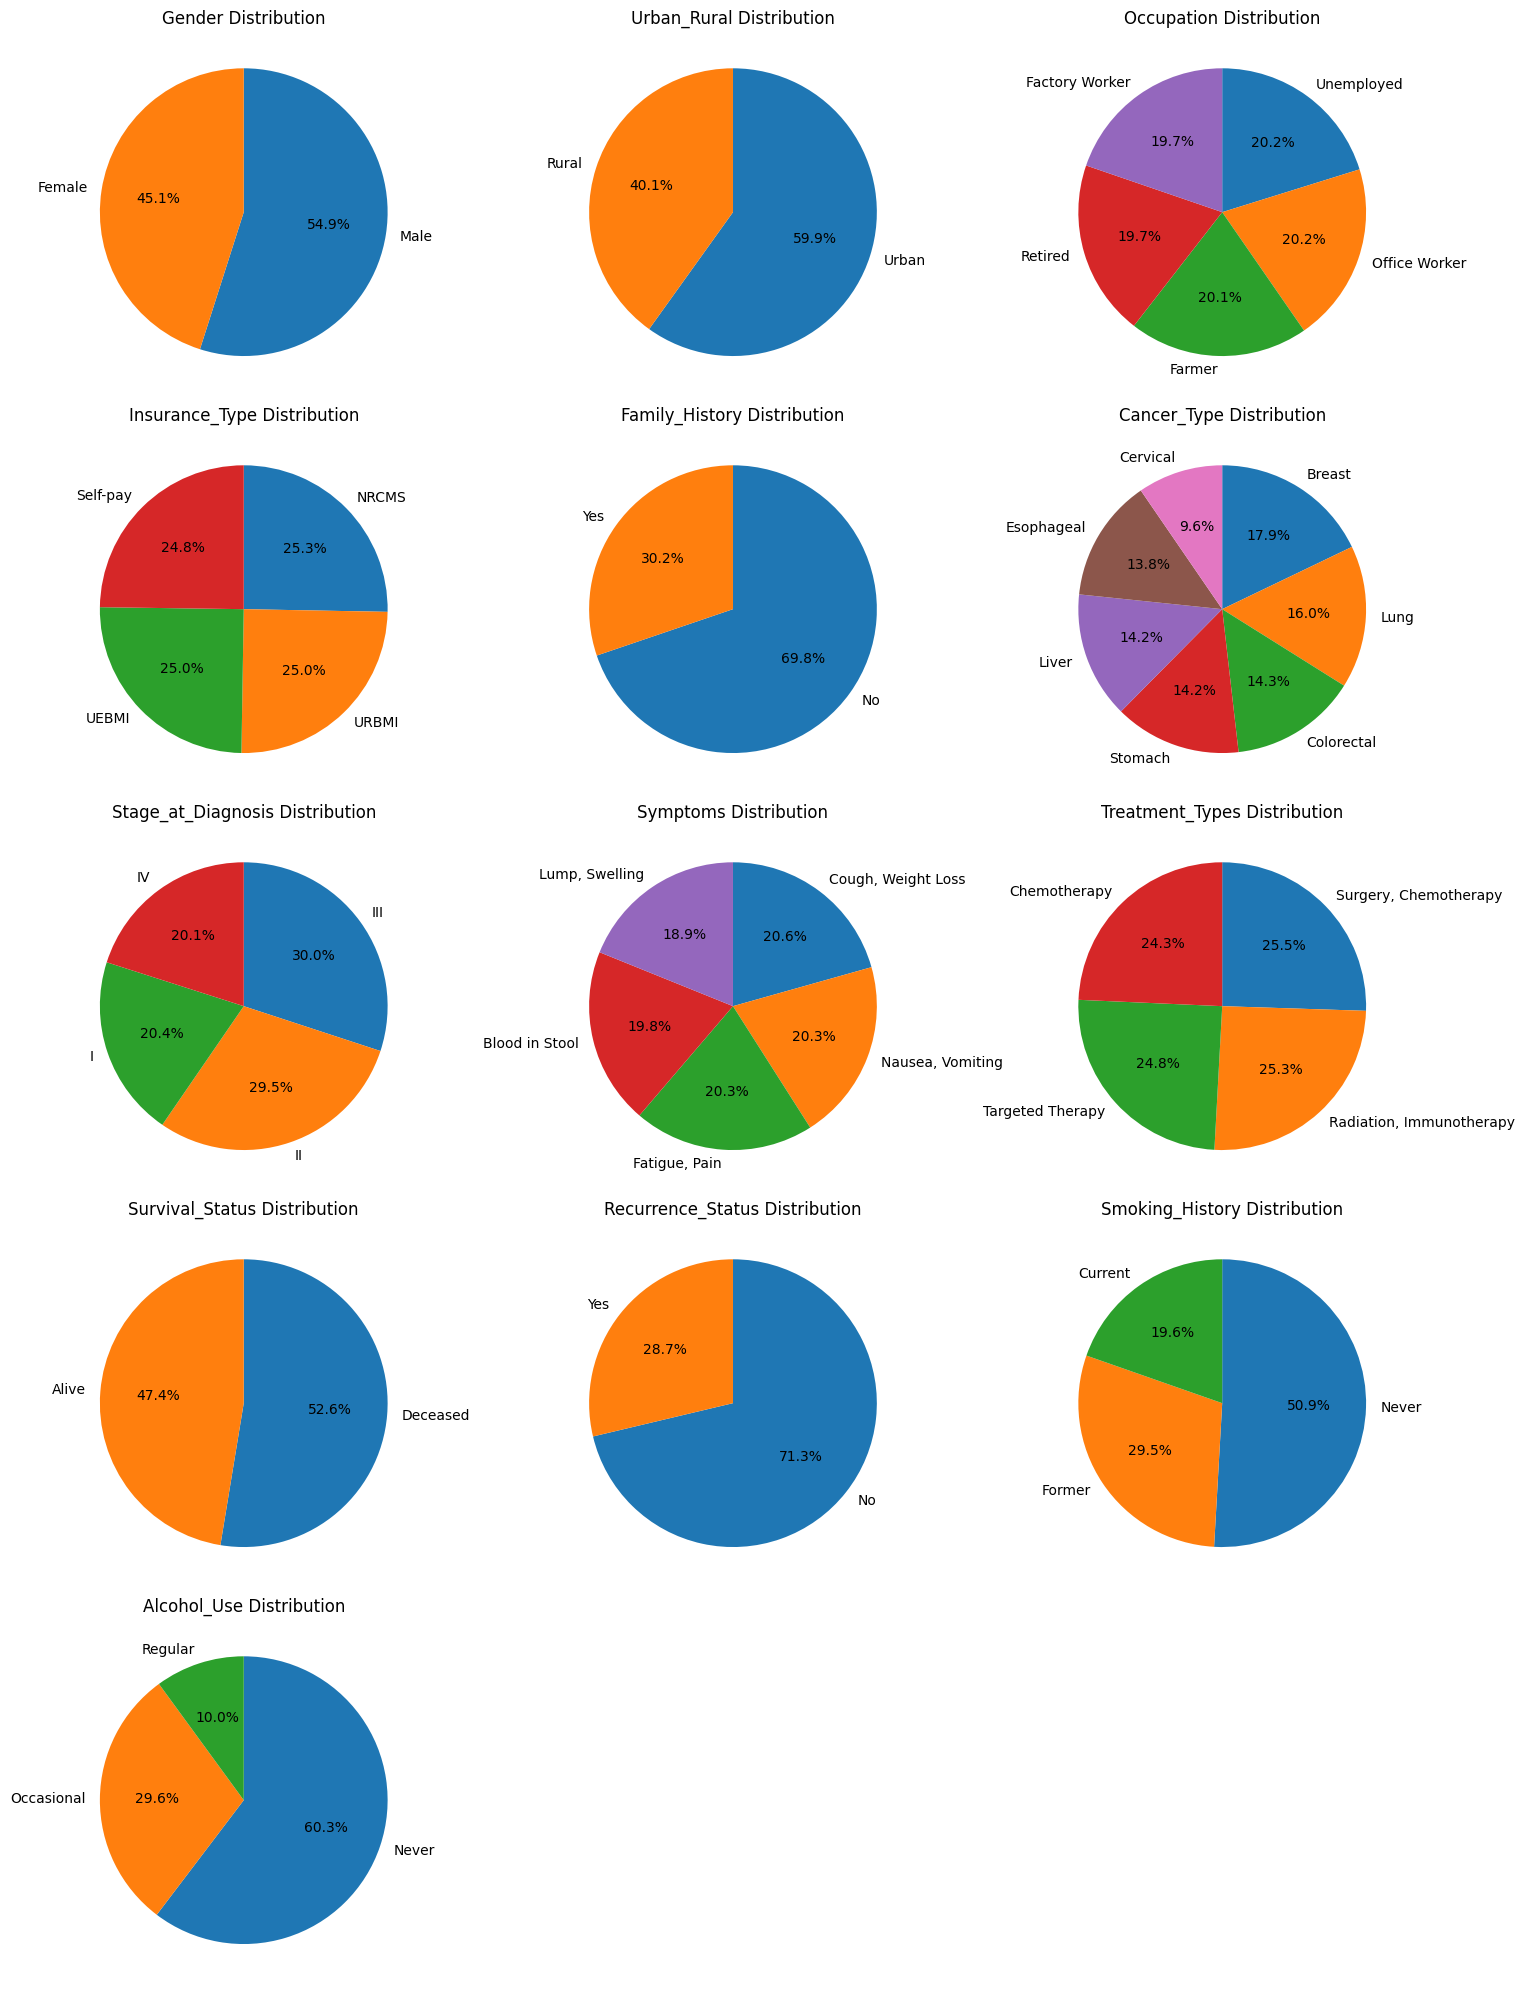

In [18]:
# Actually it might be better to use pie charts here
# Number of plots
n_cols = 3  # number of plots per row # I tried 4, but 3 is clearer
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols  # auto-calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(cols_to_plot):
    counts = cancer_to_fill[col].value_counts()

    # Plot pie chart instead of bar
    axes[i].pie(
        counts,
        labels = counts.index,
        autopct = '%1.1f%%',
        startangle = 90,
        counterclock = False
    )

    axes[i].set_title(f'{col} Distribution')

# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

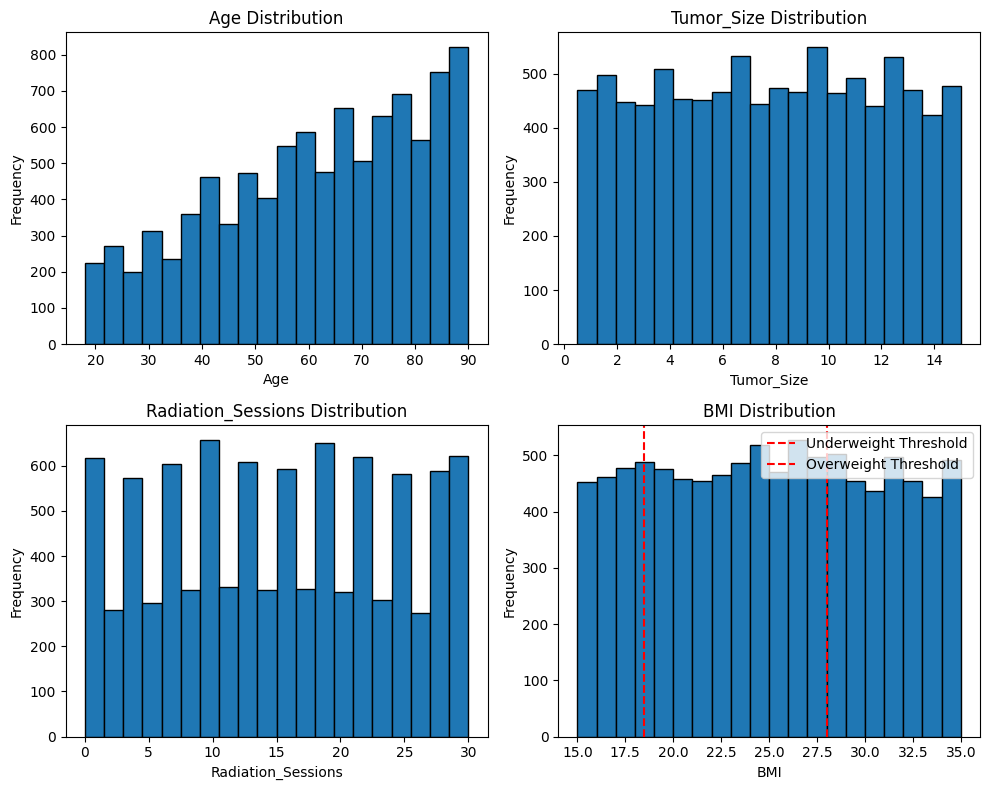

In [19]:
# Let's look at the numerical values now
# List of numeric columns you want to plot
num_cols = ['Age', 'Tumor_Size', 'Radiation_Sessions', 'BMI']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Plot histograms for each numeric column
for i, col in enumerate(num_cols):
    axes[i].hist(cancer_to_fill[col].dropna(), bins = 20, edgecolor = 'black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    # add reference lines for BMI
    if col == 'BMI':
        axes[i].axvline(x = 18.5, color = 'red', linestyle = '--', label = 'Underweight Threshold')
        axes[i].axvline(x = 28, color = 'red', linestyle = '--', label = 'Overweight Threshold')
        axes[i].legend()

# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

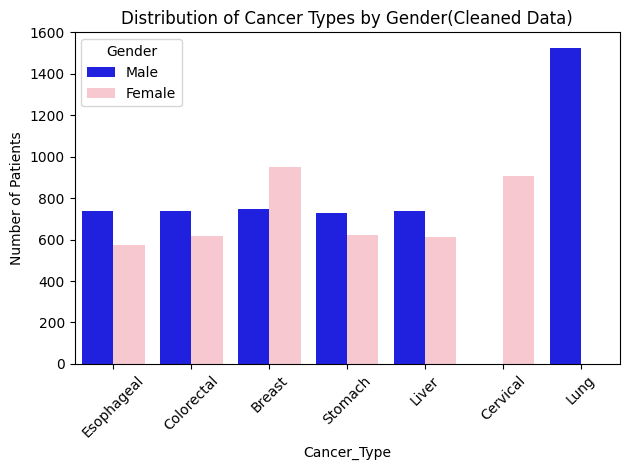

In [20]:
# We can also redo the gender-cancer type plot after we dropped some values
sns.countplot(data = cancer_to_fill, 
              x = 'Cancer_Type', 
              hue = 'Gender', 
              palette = {'Female': 'pink', 'Male': 'blue'}) # I am using stereotypical colors for gender
plt.title('Distribution of Cancer Types by Gender(Cleaned Data)')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

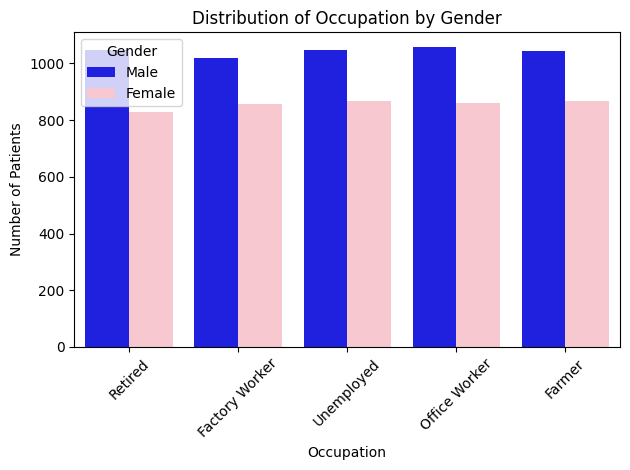

In [21]:
# we can have a similar plot with gender and occupation
sns.countplot(data = cancer_to_fill, x = 'Occupation', hue = 'Gender', palette = {'Female': 'pink', 'Male': 'blue'}) # I am using stereotypical colors for gender
plt.title('Distribution of Occupation by Gender')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

For all occupations, male are more common than female in our data. This makes sense as we do have more male patients in the data and the difference in gender districution in each occupation category is not great(approximately 200 more male patients than female). Similar gender distribution pattern appears in all types of occupations recorded in the data.

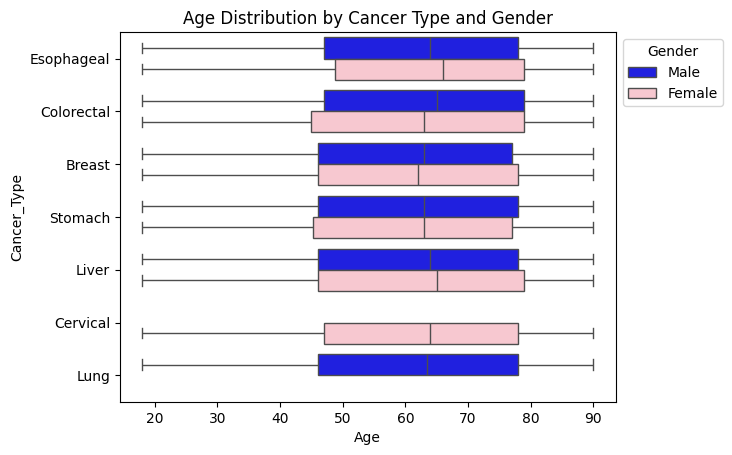

In [23]:
# how about the relationship between gender and age
pale = {'Female': 'pink', 'Male': 'blue'} # set the gender color
ax = sns.boxplot(data = cancer_to_fill, 
                 x = 'Age', 
                 y = 'Cancer_Type', 
                 orient = 'h', 
                 hue = 'Gender', 
                 palette = pale)
plt.title('Age Distribution by Cancer Type and Gender')
sns.move_legend(ax, "upper left", bbox_to_anchor = (1, 1))

We don't see great age difference for each cancer type. 

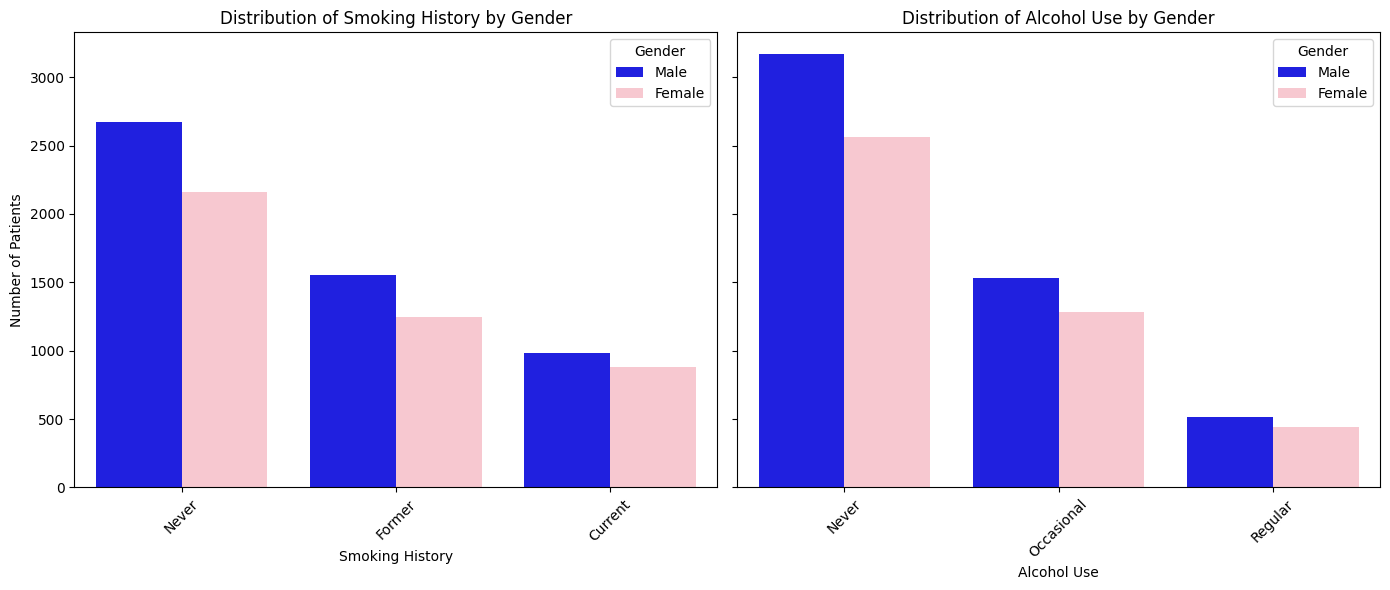

In [24]:
# explore the relationship between smoking history/alcohol use and gender
# make the 2 plots share the same y axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.countplot(
    data=cancer_to_fill,
    x='Smoking_History',
    hue='Gender',
    palette={'Female': 'pink', 'Male': 'blue'},
    ax=axes[0]
)
axes[0].set_title('Distribution of Smoking History by Gender')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Smoking History')
axes[0].tick_params(axis='x', rotation=45)


sns.countplot(
    data=cancer_to_fill,
    x='Alcohol_Use',
    hue='Gender',
    order=['Never', 'Occasional', 'Regular'],
    palette={'Female': 'pink', 'Male': 'blue'},
    ax=axes[1]
)
axes[1].set_title('Distribution of Alcohol Use by Gender')
axes[1].set_ylabel('')
axes[1].set_xlabel('Alcohol Use')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

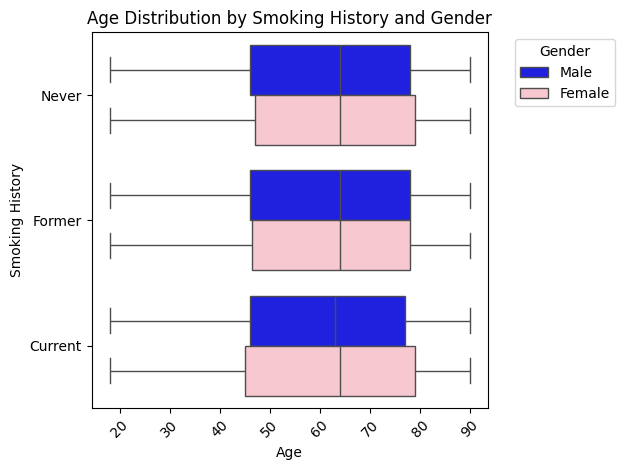

In [25]:
# Smoking_History and Alcohol_Use # any pattern in age?
sns.boxplot(
    data = cancer_to_fill,
    x = 'Age',
    y = 'Smoking_History',
    hue = 'Gender',
    palette = pale
)
plt.xticks(rotation = 45)
plt.title('Age Distribution by Smoking History and Gender')
plt.ylabel('Smoking History')
plt.xlabel('Age')
plt.legend(title = 'Gender', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.show()

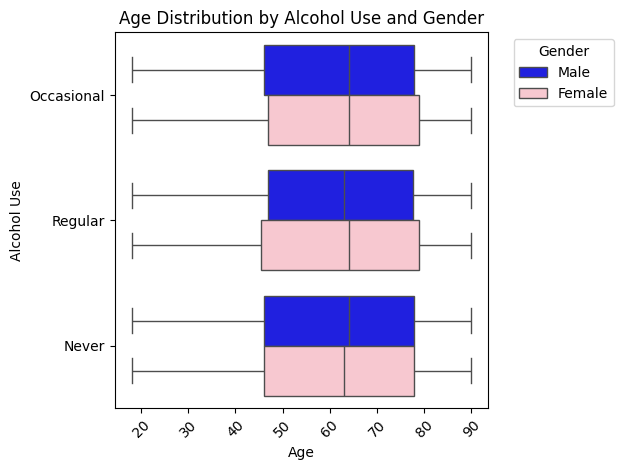

In [26]:
sns.boxplot(
    data=cancer_to_fill,
    x = 'Age',
    y = 'Alcohol_Use',
    hue = 'Gender',
    palette = pale
)
plt.xticks(rotation = 45)
plt.title('Age Distribution by Alcohol Use and Gender')
plt.ylabel('Alcohol Use')
plt.xlabel('Age')
plt.legend(title = 'Gender', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.show()

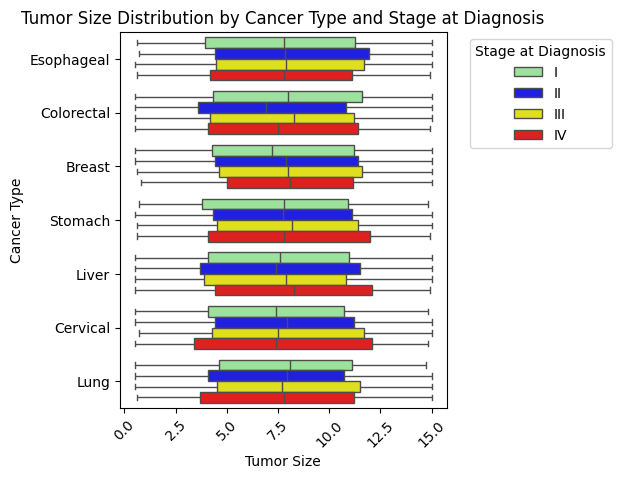

In [27]:
# let's see the tumor size disribution by cancer type and stage
stage_palette = {
    'I': 'lightgreen',
    'II': 'blue',
    'III': 'yellow',
    'IV': 'red'
}   # control the color

sns.boxplot(
    data = cancer_to_fill,
    x = 'Tumor_Size',
    y = 'Cancer_Type',
    hue = 'Stage_at_Diagnosis',
    palette = stage_palette
)
plt.xticks(rotation = 45)
plt.title('Tumor Size Distribution by Cancer Type and Stage at Diagnosis')
plt.ylabel('Cancer Type')
plt.xlabel('Tumor Size')
plt.legend(title = 'Stage at Diagnosis', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.show()

Tumor size does not necessarily increases with diagnosis stage.

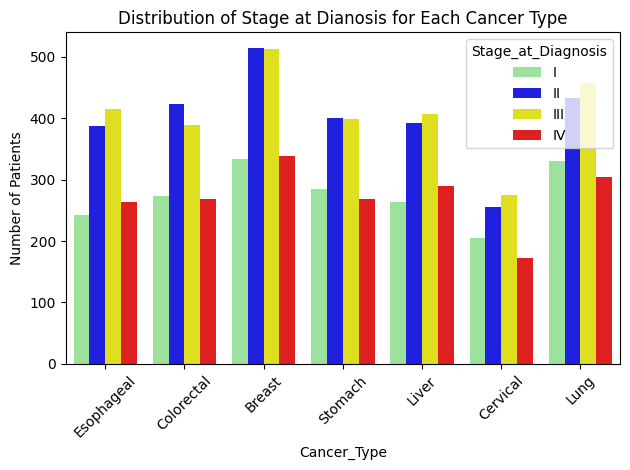

In [28]:
# count stage at disgnosis for each cancer type
sns.countplot(data = cancer_to_fill, 
              x = 'Cancer_Type', 
              hue = 'Stage_at_Diagnosis', 
              palette = stage_palette)
plt.title('Distribution of Stage at Dianosis for Each Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

It is always more common to have a disnosis at stage 2 and 3, possibly due to the emergence of symptoms.

In [42]:
# We can create a new column named "Area"(East, West) based on Province as well as the Heihe–Tengchong Line 
east_provinces = ['Henan', 'Hubei', 'Zhejiang', 'Guizhou', 'Jilin', 'Hebei', 'Hunan',
                  'Chongqing', 'Jiangxi', 'Taiwan', 'Liaoning', 'Shanxi', 'Fujian',
                  'Anhui', 'Macau', 'Shandong', 'Tianjin', 'Shanghai', 'Hong Kong',
                  'Jiangsu', 'Beijing', 'Guangdong']

cancer_to_fill['Area'] = cancer_to_fill['Province'].apply(
    lambda x: 'East' if x in east_provinces else 'West'
)

In [43]:
cancer_to_fill['Area'].value_counts()

Area
East    6533
West    2966
Name: count, dtype: int64

We have more patients(almost double) from the East than West area in China.

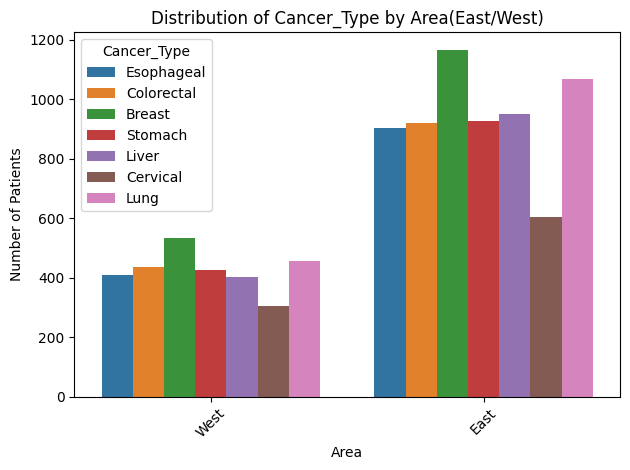

In [45]:
# let's see the distribution of cancer types based on east/west areas
sns.countplot(data = cancer_to_fill, x = 'Area', hue = 'Cancer_Type')
plt.title('Distribution of Cancer_Type by Area(East/West)')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

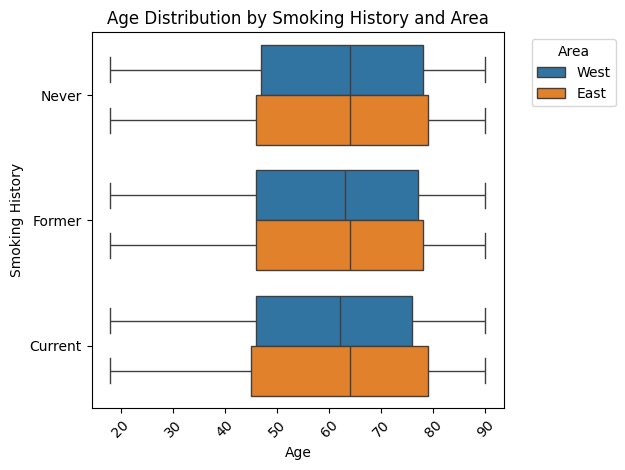

In [40]:
# Smoking History and Alcohol Use
sns.boxplot(
    data = cancer_to_fill,
    x = 'Age',
    y = 'Smoking_History',
    hue = 'Area'
)
plt.xticks(rotation=45)
plt.title('Age Distribution by Smoking History and Area')
plt.ylabel('Smoking History')
plt.xlabel('Age')
plt.legend(title = 'Area', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.show()

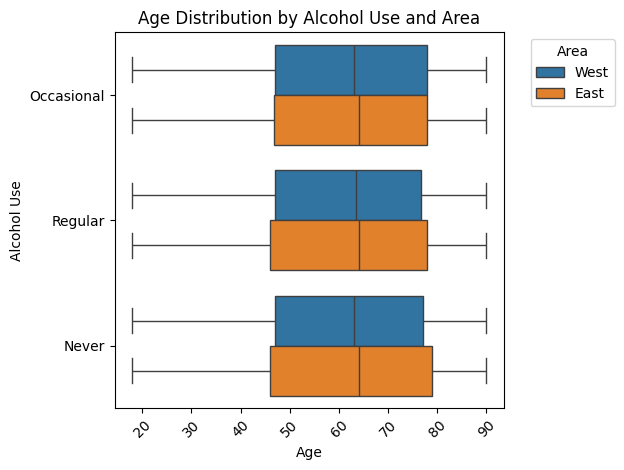

In [42]:
sns.boxplot(
    data=cancer_to_fill,
    x = 'Age',
    y = 'Alcohol_Use',
    hue = 'Area'
)
plt.xticks(rotation = 45)
plt.title('Age Distribution by Alcohol Use and Area')
plt.ylabel('Alcohol Use')
plt.xlabel('Age')
plt.legend(title = 'Area', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.show()

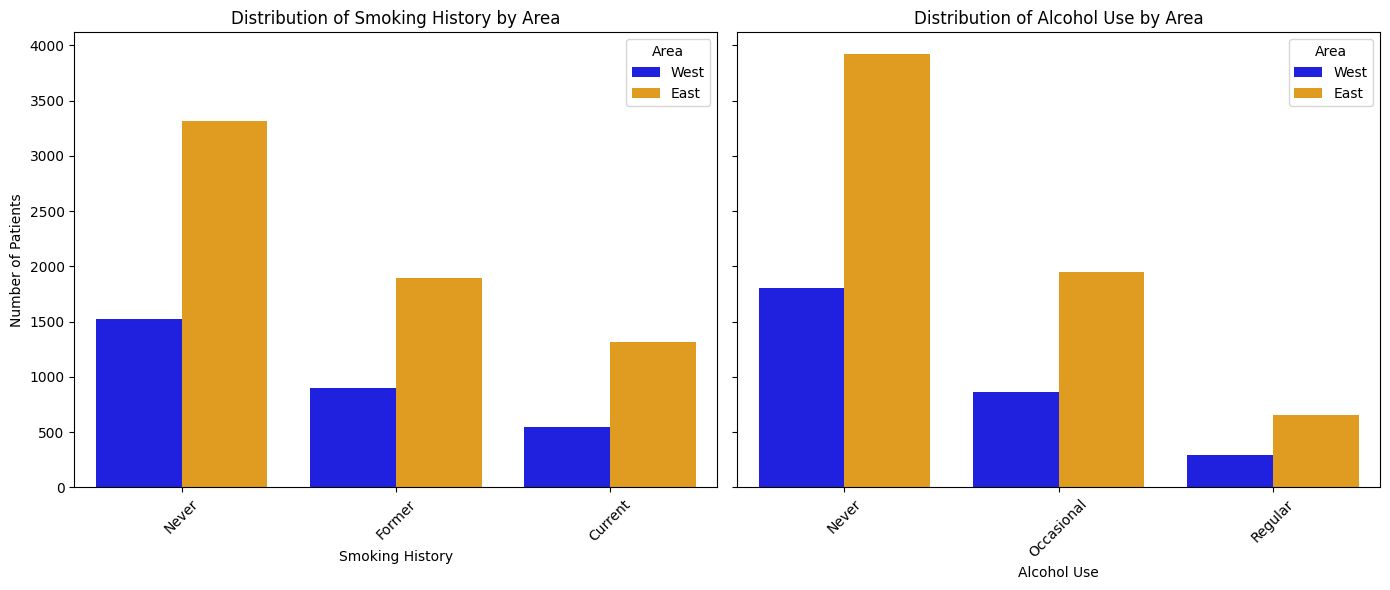

In [47]:
# apply simiilar plot we use before but now for smoking history/ alsohole use and area
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.countplot(
    data=cancer_to_fill,
    x='Smoking_History',
    hue='Area',
    palette={'East': 'orange', 'West': 'blue'},
    ax=axes[0]
)
axes[0].set_title('Distribution of Smoking History by Area')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Smoking History')
axes[0].tick_params(axis='x', rotation=45)


sns.countplot(
    data=cancer_to_fill,
    x='Alcohol_Use',
    hue='Area',
    order=['Never', 'Occasional', 'Regular'],
    palette={'East': 'orange', 'West': 'blue'},
    ax=axes[1]
)
axes[1].set_title('Distribution of Alcohol Use by Area')
axes[1].set_ylabel('')
axes[1].set_xlabel('Alcohol Use')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

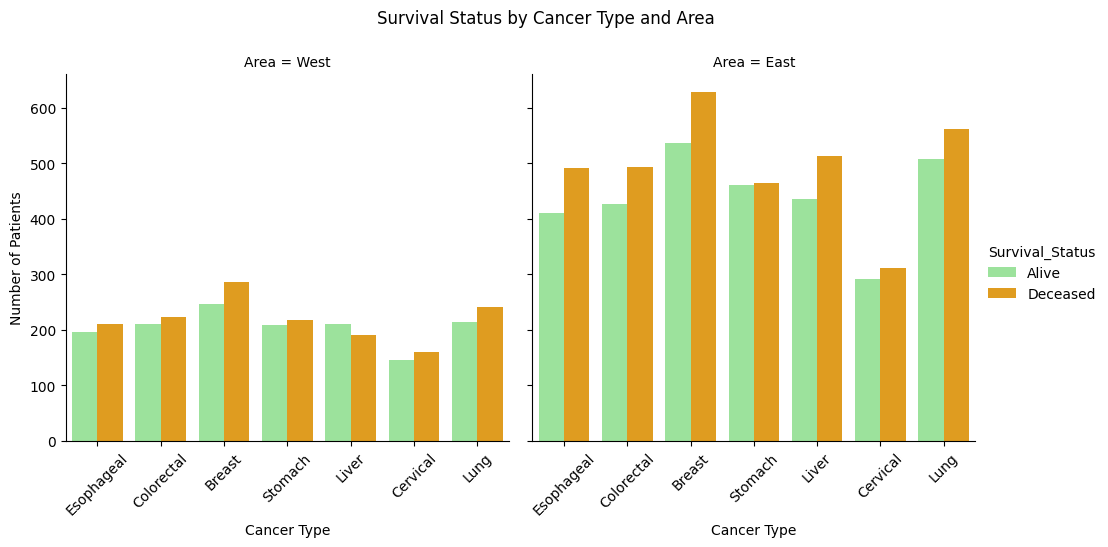

In [51]:
# check the relationship of survival status considering cancer type and area
g = sns.catplot(
    data = cancer_to_fill,
    x = "Cancer_Type",
    hue = "Survival_Status",
    col = "Area",
    kind = "count",
    palette = {"Alive": "lightgreen", "Deceased": "orange"}
)

g.set_xticklabels(rotation=45)
g.set_axis_labels("Cancer Type", "Number of Patients")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Survival Status by Cancer Type and Area")

plt.show()

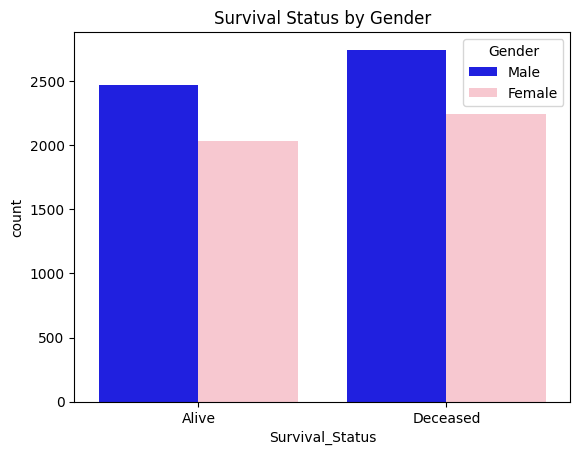

In [52]:
# how about the relationship between gender and survial status
sns.countplot(data = cancer_to_fill, x = 'Survival_Status', hue = 'Gender', palette = pale)
plt.title("Survival Status by Gender")
plt.show()

### Create some new columns or update the values in a few columns for analysis 

In [49]:
# Save the current data just in case
cancer_to_fill.to_csv('cancer_smaller_2.csv', index=False)

In [2]:
# read the file
cancer_change = pd.read_csv("cancer_smaller_2.csv")

In [3]:
# check the data
cancer_change.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9499 non-null   int64  
 1   Gender              9499 non-null   object 
 2   Province            9499 non-null   object 
 3   Urban_Rural         9499 non-null   object 
 4   Occupation          9499 non-null   object 
 5   Insurance_Type      9499 non-null   object 
 6   Family_History      9499 non-null   object 
 7   Cancer_Type         9499 non-null   object 
 8   Stage_at_Diagnosis  9499 non-null   object 
 9   Symptoms            9499 non-null   object 
 10  Tumor_Size          9499 non-null   float64
 11  Treatment_Types     9014 non-null   object 
 12  Surgery_Date        2300 non-null   object 
 13  Chemotherapy_Drugs  5652 non-null   object 
 14  Radiation_Sessions  9499 non-null   int64  
 15  Immunotherapy       9499 non-null   object 
 16  Target

In [4]:
# create a new column column "Female" based on the data in "Gender"
cancer_change['Female'] = (cancer_change['Gender'] == 'Female').astype(int)

In [5]:
# Let's now create a column "East" according to "Area"
cancer_change['East'] = (cancer_change['Area'] == 'East').astype(int)

In [6]:
# for urban_rural, let's just create a column called "Urban"
cancer_change['Urban'] = (cancer_change['Urban_Rural'] == 'Urban').astype(int)

In [7]:
# for occupation, office workers should be more well-off financially and unemployed least well-off. The others are more likely in-between.
occupation_map = {
    'Unemployed': 0,
    'Farmer': 1,
    'Factory Worker': 1,
    'Retired': 1,
    'Office Worker': 2
}

cancer_change['Occupation_Level'] = cancer_change['Occupation'].map(occupation_map)

In [8]:
# let's first check the relationship between occupation and insurance type
pd.crosstab(
    cancer_change['Occupation'],
    cancer_change['Insurance_Type'],
    rownames=['Occupation'],
    colnames=['Insurance_Type']
)

Insurance_Type,NRCMS,Self-pay,UEBMI,URBMI
Occupation,,,,
Factory Worker,483,436,502,454
Farmer,488,492,466,467
Office Worker,505,451,471,490
Retired,454,487,446,489
Unemployed,473,488,486,471


In [9]:
# What about insurance type and urban_rural
pd.crosstab(
    cancer_change['Urban_Rural'],
    cancer_change['Insurance_Type'],
    rownames=['Urban_Rural'],
    colnames=['Insurance_Type']
)

Insurance_Type,NRCMS,Self-pay,UEBMI,URBMI
Urban_Rural,,,,
Rural,939,954,986,930
Urban,1464,1400,1385,1441


Actually, for insurance type, NRCMS is usually for rural residents(in villages, likely farmers), URBMI is for Urban residents not formally employed (e.g. children, students, elderly, unemployed), UEBMI is for Urban employees. While I expect to see a type of insurance strongly associated with an occupation or an area, it is not that case based on the data.

In [10]:
# Drop old columns
cancer_change.drop(['Gender','Province', 'Area', 'Urban_Rural', 'Occupation'], axis = 1, inplace = True)
# I was doing this step after creating all the new columns but it went chaotic

In [11]:
cancer_change = pd.get_dummies(cancer_change, columns=['Insurance_Type'], dtype = 'int') # create dummy columns for insurance

In [12]:
# update Family_History
cancer_change['Family_History'] = cancer_change['Family_History'].map({'Yes': 1, 'No': 0})

In [13]:
# get dummy columns for Cancer_Type
cancer_change = pd.get_dummies(cancer_change, columns=['Cancer_Type'], dtype = 'int')

In [14]:
# the same for Stage_at_Diagnosis
cancer_change = pd.get_dummies(cancer_change, columns=['Stage_at_Diagnosis'], dtype = 'int')

In [15]:
# Symptoms
cancer_change = pd.get_dummies(cancer_change, columns=['Symptoms'], dtype = 'int')

In [16]:
# Create a new column "Surgery" and assign value 1 if "Surgery_Date" is not missing and 0 otherwise
cancer_change['Surgery'] = cancer_change['Surgery_Date'].notna().astype(int)
# create a new column "Drug" based on "Chemotherapy_Drugs"
cancer_change['Drug'] = cancer_change['Chemotherapy_Drugs'].notna().astype(int)

In [17]:
# For Immunotherapy and Targeted_Therapy, they already have "true/false" values, update them with 1/0
cancer_change['Immunotherapy'] = cancer_change['Immunotherapy'].map({'Yes': 1, 'No': 0})
cancer_change['Targeted_Therapy'] = cancer_change['Targeted_Therapy'].map({'Yes': 1, 'No': 0})

In [18]:
# change the target value to 1 and 0
cancer_change['Survived'] = cancer_change['Survival_Status'].map({'Alive': 1, 'Deceased': 0})

In [19]:
# update Recurrence_Status with value 1/0
cancer_change['Recurrence_Status'] = cancer_change['Recurrence_Status'].map({'Yes': 1, 'No': 0})

In [20]:
# get dummy columns for Smoking_History and Alcohol_Use
cancer_change = pd.get_dummies(cancer_change, columns=['Smoking_History'], dtype = 'int')
cancer_change = pd.get_dummies(cancer_change, columns=['Alcohol_Use'], dtype = 'int')

In [21]:
# Time to drop old columns again
cancer_change.drop(['Surgery_Date', 'Chemotherapy_Drugs', 'Survival_Status', 'Treatment_Types'], axis = 1, inplace = True)

In [22]:
# Check the current data
display(cancer_change.head())

cancer_change.info()

,Age,Family_History,Tumor_Size,Radiation_Sessions,Immunotherapy,Targeted_Therapy,Recurrence_Status,BMI,Female,East,...,"Symptoms_Nausea, Vomiting",Surgery,Drug,Survived,Smoking_History_Current,Smoking_History_Former,Smoking_History_Never,Alcohol_Use_Never,Alcohol_Use_Occasional,Alcohol_Use_Regular
0,70,0,9.5,26,0,1,0,19.0,0,0,...,0,1,1,1,0,0,1,0,1,0
1,71,0,12.6,29,0,0,0,32.9,0,1,...,0,1,1,1,0,1,0,0,0,1
2,42,0,0.7,10,1,0,1,32.3,0,1,...,1,1,0,0,0,0,1,1,0,0
3,56,0,4.2,9,0,1,0,20.0,1,1,...,1,0,1,0,0,1,0,0,0,1
4,29,0,13.5,29,1,0,1,28.8,0,1,...,0,1,0,1,0,1,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          9499 non-null   int64  
 1   Family_History               9499 non-null   int64  
 2   Tumor_Size                   9499 non-null   float64
 3   Radiation_Sessions           9499 non-null   int64  
 4   Immunotherapy                9499 non-null   int64  
 5   Targeted_Therapy             9499 non-null   int64  
 6   Recurrence_Status            9499 non-null   int64  
 7   BMI                          9499 non-null   float64
 8   Female                       9499 non-null   int64  
 9   East                         9499 non-null   int64  
 10  Urban                        9499 non-null   int64  
 11  Occupation_Level             9499 non-null   int64  
 12  Insurance_Type_NRCMS         9499 non-null   int64  
 13  Insurance_Type_Sel

In [23]:
# check "Family_History" just in case(we did not see a row with 1 in the first 5 rows) 
cancer_change[cancer_change['Family_History'] == 1].head()

,Age,Family_History,Tumor_Size,Radiation_Sessions,Immunotherapy,Targeted_Therapy,Recurrence_Status,BMI,Female,East,...,"Symptoms_Nausea, Vomiting",Surgery,Drug,Survived,Smoking_History_Current,Smoking_History_Former,Smoking_History_Never,Alcohol_Use_Never,Alcohol_Use_Occasional,Alcohol_Use_Regular
5,44,1,7.8,18,0,0,1,19.8,1,1,...,0,1,1,0,0,1,0,0,1,0
9,88,1,6.2,14,0,1,0,29.0,0,1,...,0,0,1,1,0,1,0,0,1,0
10,81,1,8.9,29,1,0,1,17.5,1,1,...,0,0,0,1,1,0,0,1,0,0
11,78,1,5.0,25,0,0,0,27.7,1,1,...,1,1,1,1,0,0,1,0,1,0
15,89,1,14.8,30,0,0,1,23.5,1,0,...,1,1,1,0,0,1,0,1,0,0


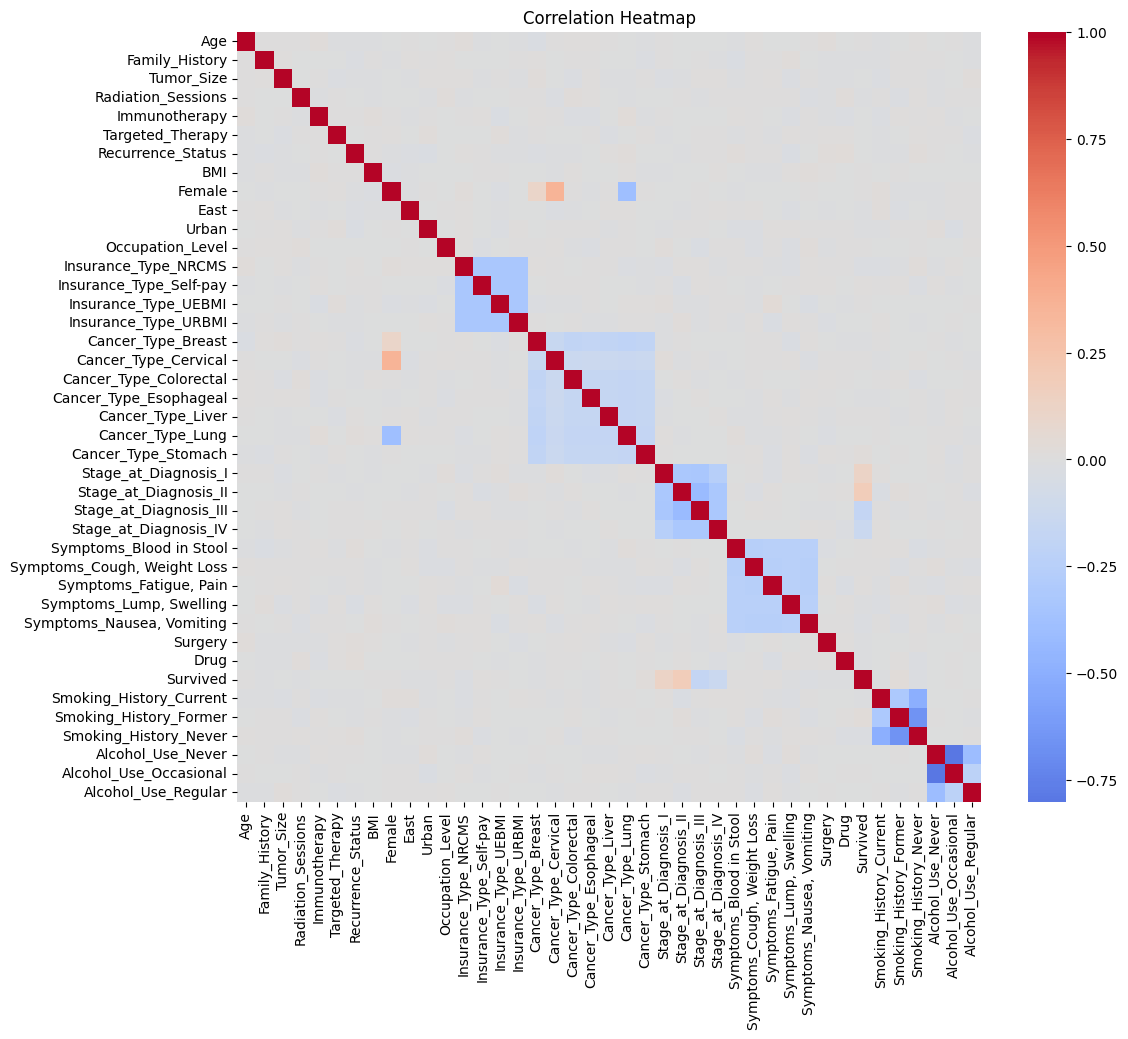

In [24]:
# Compute correlation matrix
corr = cancer_change.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

Female is correlated with Cervical cancer. Survival Status seems to be positively correlated with being diagnosised at a relatively early stage and negatively correlated with being diagnosised at a later stage.

In [25]:
# Save the data again
cancer_change.to_csv('cancer_for_model.csv', index=False)

In [2]:
# import the data
cancer = pd.read_csv('cancer_for_model.csv')

In [3]:
# Import libraries 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # for 8:2 splitting the data and cross validation
from sklearn.preprocessing import StandardScaler # scale numerical values(mainly for logistic regression)
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier # the two models we want
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report  # evaluation

In [4]:
# Select the columns to be scaled
col_list = ['Age', 'Tumor_Size', 'Radiation_Sessions', 'BMI']
# set a scaler
scaler = StandardScaler()

# create independent variables X and target(dependent variable) y
X = cancer.drop(columns = ['Survived'])
y = cancer['Survived']

# split the data to training and testing sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Fit the scaler on training data
scaler.fit(X_train[col_list])

# Transform both train and test sets
X_train[col_list] = scaler.transform(X_train[col_list])
X_test[col_list] = scaler.transform(X_test[col_list])

In [5]:
# We are going to do both logit regression and randon forest
logit = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=200)

In [6]:
# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
# Evaluate my models with cross-validation first
logit_auc = cross_val_score(logit, X, y, cv=cv, scoring='roc_auc')
rf_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
# Show the AUC 
print("Logistic Regression AUC: {:.3f} ± {:.3f}".format(logit_auc.mean(), logit_auc.std()))
print("Random Forest AUC:       {:.3f} ± {:.3f}".format(rf_auc.mean(), rf_auc.std()))

Logistic Regression AUC: 0.628 ± 0.016
Random Forest AUC:       0.628 ± 0.013


Both models are rather weak and only slightly better than random guessing.

In [8]:
# actually the problem is mainly from the original data.
# It does not contain a lot of info regarding the patients' health condiction(like the data you get after having a helath check)
# but rather a lot of info concering socio-economic background. This is what we want for this research of course, to see if these features influence the survival outcome.
# let's try to improve the models anyway.

# Try to tune logit regression
from sklearn.model_selection import GridSearchCV

# help me find the best parameter
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid_logit = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                          param_grid, cv=5, scoring='roc_auc')
# fit on training data
grid_logit.fit(X_train, y_train)

print(grid_logit.best_params_)

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [9]:
# Now we can get the best logistic model using the parameters we have found
best_logit = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [10]:
# Tune the random forest model
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
# fit on training data to find the best parameters
grid_rf.fit(X_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)

Best Random Forest Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [11]:
# the best random forest
best_rf = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

In [12]:
# fit the models
best_logit.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# do the cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logit_auc = cross_val_score(best_logit, X_train, y_train, cv=cv, scoring='roc_auc')
rf_auc = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-validation AUC (Training data):")
print(f"Logistic Regression: {logit_auc.mean():.3f} ± {logit_auc.std():.3f}")
print(f"Random Forest:       {rf_auc.mean():.3f} ± {rf_auc.std():.3f}")


Cross-validation AUC (Training data):
Logistic Regression: 0.633 ± 0.014
Random Forest:       0.638 ± 0.005


Yes, it does not improve much. The main problem is the data, we do not have a lot of clinical factors but rather socioeconomic data. Intuitively, it would be much more effective to predict survival status based on the health condition of a patient. Using this data can be viewed as an exploration.

In [22]:
# Evaluate on the test set(logit)
y_pred_logit = best_logit.predict(X_test)
y_prob_logit = best_logit.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression (Tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logit))
print(classification_report(y_test, y_pred_logit))


=== Logistic Regression (Tuned) ===
Accuracy: 0.62
ROC-AUC: 0.6132081026642625
              precision    recall  f1-score   support

           0       0.64      0.62      0.63       999
           1       0.59      0.62      0.61       901

    accuracy                           0.62      1900
   macro avg       0.62      0.62      0.62      1900
weighted avg       0.62      0.62      0.62      1900



Precision (“How many of the predicted survivors/deceased indivisuals were actually survivors/deceased?”)  
Recall (“How many actual survivors/deceased individuals did we correctly find?”)  
F1-Score (“Balance between precision and recall”)

When the model predicts a patient to be "deceased"(0), 64% of the times is the patient actually deceased. The performance is slight worse for "survived"(0.59). Of all actual survivors, about 62% were correctly captured by the logistic regression model. The same performance applies to capturing actual deceased individuals. The overall accuracy of the model is 0.62.

In [23]:
#  confusion matrix using y_pred_logit and y_pred_rf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_norm_lr = confusion_matrix(y_test, y_pred_logit, 
                      labels = best_logit.classes_, 
                      normalize = 'true')

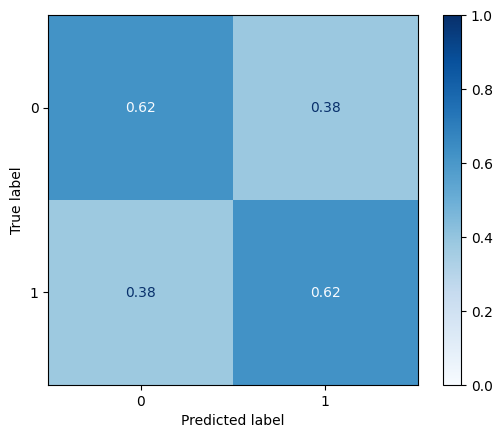

In [24]:
# the plots
disp_lr = ConfusionMatrixDisplay(cm_norm_lr, 
                              display_labels = best_logit.classes_)
disp_lr.plot(cmap='Blues', im_kw={"vmin": 0, "vmax": 1})

In [25]:
# view in the dataframe
cm_norm_lr_df = pd.DataFrame(
    cm_norm_lr,
    index=pd.Index(best_logit.classes_, name="True label"),
    columns=pd.Index(best_logit.classes_, name="Predicted label")
)
print('Survival Status Prediction (Logistic Regression):')
cm_norm_lr_df

Survival Status Prediction (Logistic Regression):


Predicted label,0,1
True label,,
0,0.617618,0.382382
1,0.377358,0.622642


In [26]:
# do the same for random forest
# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== Random Forest (Tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))


=== Random Forest (Tuned) ===
Accuracy: 0.6078947368421053
ROC-AUC: 0.6149234695294629
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       999
           1       0.59      0.59      0.59       901

    accuracy                           0.61      1900
   macro avg       0.61      0.61      0.61      1900
weighted avg       0.61      0.61      0.61      1900



Very similar performance as the logistic regression but slightly worse overall accuracy. The random forest model is slight worse at capturing actual survivor than logistic regression.

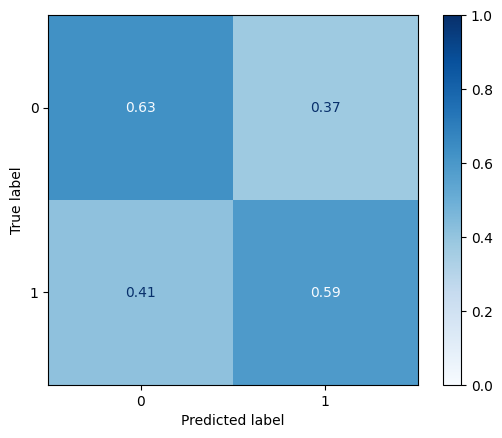

In [19]:
# the confusion matrix
cm_norm_rf = confusion_matrix(y_test, y_pred_rf, 
                      labels = best_rf.classes_, 
                      normalize = 'true')

disp_rf = ConfusionMatrixDisplay(cm_norm_rf, 
                              display_labels = best_rf.classes_)
disp_rf.plot(cmap='Blues', im_kw={"vmin": 0, "vmax": 1})

Slight better at predicting whether the patient has deceased.

In [20]:
# view in the dataframe
cm_norm_rf_df = pd.DataFrame(
    cm_norm_rf,
    index=pd.Index(best_rf.classes_, name="True label"),
    columns=pd.Index(best_rf.classes_, name="Predicted label")
)

print('Survival Status Prediction (Random Forest):')
cm_norm_rf_df

Survival Status Prediction (Random Forest):


Predicted label,0,1
True label,,
0,0.626627,0.373373
1,0.412875,0.587125


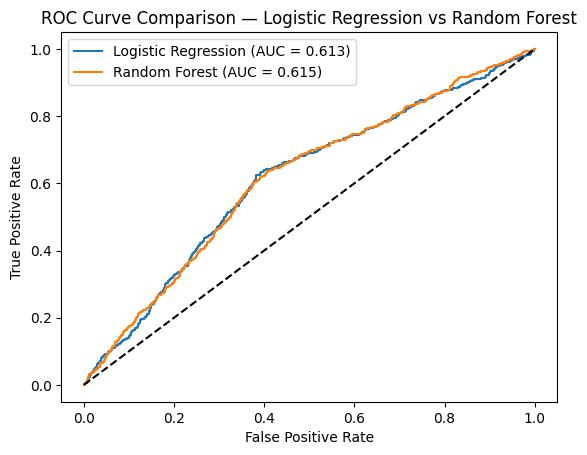

In [29]:
# Plot ROC curve in the same plot
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.3f})'.format(roc_auc_score(y_test, y_prob_logit)))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.3f})'.format(roc_auc_score(y_test, y_prob_rf)))
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve Comparison — Logistic Regression vs Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

The performance of both models are limited due to the data we have. While we intend to include socioeconimic data into consideration for the prediction, the data was not able to include more clinical data regarding the health of the patient. As most variables are socioeconomic related and one hot encoded for the algorithm, limited nonlinear complex relationship in the data can be expected.

In [30]:
import shap

# perform SHAP for Logistic Regression
explainer_lr = shap.LinearExplainer(best_logit, X_train, feature_perturbation="interventional")
shap_values_lr = explainer_lr.shap_values(X_train)

# Absolute SHAP shows how strong the feature was, regardless of direction.
imp_lr = np.abs(shap_values_lr).mean(axis=0)
imp_lr = pd.Series(imp_lr, index=X_train.columns)

C:\Users\wangy\anaconda3\envs\myprofile-env\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [31]:
# show only the top features for this model
imp_lr = imp_lr.sort_values(ascending=False)

print("Top 15 Features for Logistic Regression(SHAP Importance):")
print(imp_lr.head(15))

Top 15 Features for Logistic Regression(SHAP Importance):
Stage_at_Diagnosis_III       0.228895
Stage_at_Diagnosis_II        0.219852
Stage_at_Diagnosis_IV        0.176383
Stage_at_Diagnosis_I         0.164186
Smoking_History_Former       0.039119
Age                          0.036603
Cancer_Type_Breast           0.014374
Family_History               0.014222
Cancer_Type_Stomach          0.013711
Insurance_Type_NRCMS         0.012078
Symptoms_Nausea, Vomiting    0.011474
Cancer_Type_Colorectal       0.011076
Radiation_Sessions           0.010766
Insurance_Type_Self-pay      0.009810
Tumor_Size                   0.006954
dtype: float64


For logistic rgression, we can simply check the coefficients of variables to see how important they are to the prediction.

In [14]:
# do the same for random forest
#explainer_rf = shap.TreeExplainer(best_rf)
#shap_values_rf = explainer_rf.shap_values(X_train)[1]  # SHAP values for class 1

#imp_rf = np.abs(shap_values_rf).mean(axis=0)
#imp_rf = pd.Series(imp_rf, index=X_train.columns)
# this took too long

In [32]:
# To speed up the process of doing SHAP for random forest model
# we will just use a subset of training data
sam = X_train.sample(1000, random_state=42)

masker = shap.maskers.Independent(X_train, max_samples=50)

explainer_rf = shap.TreeExplainer(best_rf, data = masker, approximate=True)
shap_values_rf = explainer_rf(sam)

values = shap_values_rf.values

# handle multi-output case
if values.ndim == 3:
    values = values[:, :, 1]   # select SHAP for positive class

imp_rf = np.abs(values).mean(axis=0)
imp_rf = pd.Series(imp_rf, index=X_train.columns)

100%|===================| 1996/2000 [02:03<00:00]        

In [33]:
# show only the top features for this model
imp_rf = imp_rf.sort_values(ascending=False)

print("Top 15 Features for Random Forest(SHAP Importance):")
print(imp_rf.head(15))

Top 15 Features for Random Forest(SHAP Importance):
Stage_at_Diagnosis_II     0.046141
Stage_at_Diagnosis_III    0.044868
Stage_at_Diagnosis_IV     0.035278
Stage_at_Diagnosis_I      0.033274
Age                       0.014568
Tumor_Size                0.013952
BMI                       0.013599
Radiation_Sessions        0.012798
Occupation_Level          0.006727
Smoking_History_Former    0.006371
Smoking_History_Never     0.004982
Female                    0.004969
Insurance_Type_UEBMI      0.004935
Cancer_Type_Breast        0.004791
Immunotherapy             0.004687
dtype: float64


We can see a few important features based on SHAP importance values but we need visualization to see "how" these variables affect the final prediction.

Top positive coefficients (increase survival probability):
Stage_at_Diagnosis_II      0.542532
Stage_at_Diagnosis_I       0.517215
Smoking_History_Former     0.089483
Cancer_Type_Stomach        0.047022
Age                        0.043374
Insurance_Type_Self-pay    0.026626
dtype: float64

Top negative coefficients (decrease survival probability):
Stage_at_Diagnosis_IV       -0.550083
Stage_at_Diagnosis_III      -0.525227
Cancer_Type_Colorectal      -0.052294
Cancer_Type_Breast          -0.052026
Family_History              -0.035437
Symptoms_Nausea, Vomiting   -0.032750
Insurance_Type_NRCMS        -0.030872
Radiation_Sessions          -0.012293
Tumor_Size                  -0.008037
dtype: float64


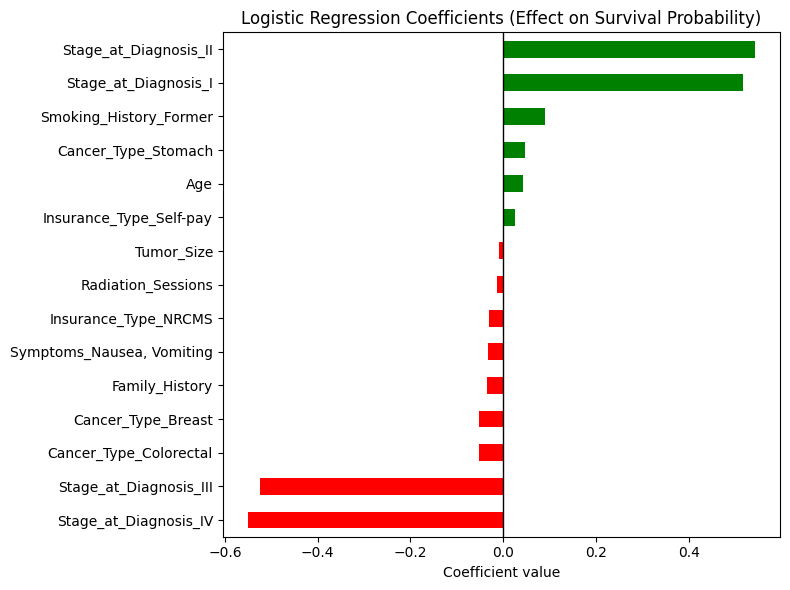

In [34]:
# Coefficients from the tuned Logistic Regression model(this is not about SHAP)
coef = pd.Series(best_logit.coef_[0], index=X_train.columns)
top15_lr = coef.abs().sort_values(ascending=False).head(15).index  # the top 15 features with the greatest absolute coefficients
coef_sorted = coef[top15_lr].sort_values()

# Show the top positive and negative coefficients
print("Top positive coefficients (increase survival probability):")
print(coef_sorted[coef_sorted > 0].sort_values(ascending=False))

print("\nTop negative coefficients (decrease survival probability):")
print(coef_sorted[coef_sorted < 0].sort_values())

# Plot the coefficients
plt.figure(figsize=(8,6))

# the original plot is not so clear so we color the bars red if they affect the target negaticely and green other wise
colors = ['red' if v < 0 else 'green' for v in coef_sorted]
coef_sorted.plot(kind='barh', color=colors)

# Add vertical line at 0 so it is clearer
plt.axvline(0, color='black', linewidth=1)

plt.title("Logistic Regression Coefficients (Effect on Survival Probability)")
plt.xlabel("Coefficient value")

plt.tight_layout()
plt.show()

Looking at the coefficients, Stage at Diagnosis plays a vital role. The longer the cancer develops, the less likely a patient will survive. Early disnosis helps increase survival chance.

In [35]:
# a list of the names of the 15 important features in random forest
selected_features_rf = imp_rf.head(15).index.tolist()

In [36]:
# column indices of the top 15 features/columns
cols_15 = [X_train.columns.get_loc(f) for f in selected_features_rf]
print(cols_15)

[24, 25, 26, 23, 0, 2, 7, 3, 11, 35, 36, 8, 14, 16, 4]


In [37]:
# filter SHAP values to top 15 features
# print(values)
values_15 = values[:, cols_15]

In [38]:
# keep only the 15 important features in the sample
sam_15 = sam[selected_features_rf]

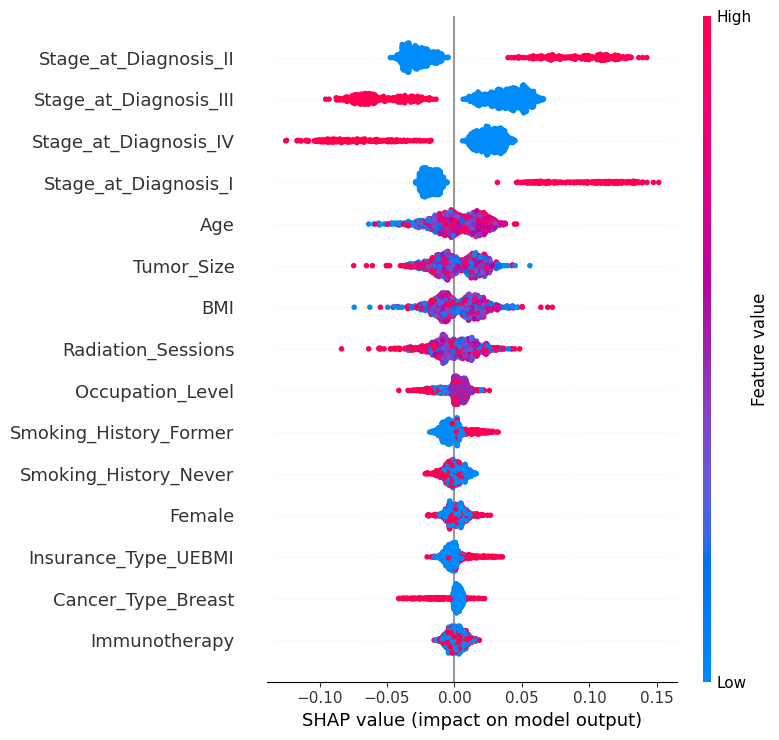

In [39]:
# summary plot
shap.summary_plot(values_15, sam_15, feature_names=selected_features_rf)

In the summary plot, a red point means high value and a blue point mean low value. We only find very clear separation of points based on stage at diagnosis. For patients diagnosed at an early stage(high value 1 in Stage_at_Diagnosis_I or Stage_at_Diagnosis_II), the dots are all on the right side of the plot which increase the predicted probability of survival. Yet, for patients with value 1 in tage_at_Diagnosis_	III or Stage_at_Diagnosis_IV, the red dots are leading the prediction more towards deceased.

In [40]:
# shap.summary_plot(values, sam, feature_names=X_train.columns)
# simply doing this is also fine, by default, the plot will only show 20 top features

## Conclusion

Logistic regression can predict the survival status at an overall accuracy at 62%. The application of this model could be that for patients with a low likelihood of survival(predicted), hospitals and social services should intervene to consider whether to provide more palliative care aimed at reducing suffering rather than aggressive treatment, and offer more frequent psychological support for both patients and their families than for those with a higher expected survival chance.  

The model does not decide the fate of the patients(any kind of treatment must be applied to increase the survival chance of patients) and the prediction results must not be revealed to the patients or the family members. Instead, the model provides a "suggestion" on proving more humanistic care(treatment with dignity and mental support).

In sum, this research acknowledged the importance of early diagosis for improving cancer patients' survival outcome. While the performances of our models are limited, we managed to explore if and how socioeconomic background of a patient can affect his/her survival status. The conclusion is that where the patients live, how much they are expected to earn, their insurance type etc. do not make meaningful contributiton to prediting survival. We must admit, the date we are currently using could be improved by including more clinical data as in the research the impact of socioeconomic data is trivial as well as increasing the size of the data for 10,000 entries are insufficient for accurately predicting a complex outcome.